<a href="https://colab.research.google.com/github/Sagnik789/CausalInference/blob/main/CasusalInference4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install dowhy scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 101.6 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from dowhy import CausalModel

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use("default")

mpl.rcParams.update({
    "figure.dpi":300,
    "savefig.dpi":300,

    "font.family":"DejaVu Sans",

    "axes.titlesize":22,
    "axes.titleweight":"bold",

    "axes.labelsize":18,

    "xtick.labelsize":14,
    "ytick.labelsize":14,

    "legend.fontsize":14,

    "axes.spines.top":False,
    "axes.spines.right":False,

    "axes.linewidth":1.3,

    "grid.alpha":0.25,

    "figure.facecolor":"white",
    "axes.facecolor":"white"
})

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Telecom_Causal_Inference_Modified_Data.csv"

df = pd.read_csv(DATA_PATH)

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df.shape)
display(df.head())

(7043, 46)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Original_Churn,Original_Churn_Flag,Month_to_Month_Flag,Fiber_Flag,Electronic_Check_Flag,No_OnlineSecurity_Flag,No_TechSupport_Flag,High_ARPU_Flag,Low_Tenure_Flag,Medium_Tenure_Flag,Risk_Segment,True_Propensity,Received_Offer,Churn_Probability_No_Offer,Churn_Probability_With_Offer,True_Treatment_Effect,Churn_Final_Flag,Churn_Final,Offer_Cost,Customer_Value,Expected_Revenue_Saved,Expected_Net_Value,Estimated_Propensity,ps_clip,ipw_weight
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No,0,1,0,1,1,1,0,1,0,Medium Risk,0.768525,0,0.417949,0.292949,-0.125000,0,No,0.0,350.0,0.0,0.0,0.710231,0.710231,3.451030
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,No,0,0,0,0,0,1,0,0,1,Low Risk,0.167982,1,0.065107,0.040107,-0.025000,0,No,10.0,500.0,12.5,2.5,0.218878,0.218878,4.568746
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Yes,1,1,0,0,0,1,0,1,0,Medium Risk,0.668188,1,0.261304,0.136304,-0.125000,0,No,10.0,500.0,62.5,52.5,0.691720,0.691720,1.445671
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,No,0,0,0,0,0,0,0,0,0,Low Risk,0.167982,0,0.031322,0.010000,-0.021322,0,No,0.0,350.0,0.0,0.0,0.107681,0.107681,1.120675
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Yes,1,1,1,1,1,1,1,1,0,High Risk,0.920000,1,0.749435,0.479435,-0.270000,1,Yes,10.0,500.0,135.0,125.0,0.916231,0.916231,1.091428


In [ ]:
TREATMENT = "Received_Offer"
OUTCOME = "Churn_Final_Flag"

BASELINE_COLS = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

BASELINE_COLS = [c for c in BASELINE_COLS if c in df.columns]

df = df.dropna(subset=[TREATMENT, OUTCOME]).copy()
df[TREATMENT] = df[TREATMENT].astype(int)
df[OUTCOME] = df[OUTCOME].astype(int)

print("Baseline variables used:")
print(BASELINE_COLS)

Baseline variables used:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ---------------------------------------
# Prepare data
# ---------------------------------------
X_rank = df[BASELINE_COLS].copy()

num_cols = [
    c for c in BASELINE_COLS
    if pd.api.types.is_numeric_dtype(X_rank[c])
]

cat_cols = [
    c for c in BASELINE_COLS
    if c not in num_cols
]

for c in num_cols:
    X_rank[c] = pd.to_numeric(
        X_rank[c],
        errors="coerce"
    ).fillna(X_rank[c].median())

for c in cat_cols:
    X_rank[c] = X_rank[c].fillna("Missing").astype(str)

# One-hot encode
X_dummy = pd.get_dummies(
    X_rank,
    drop_first=True
)

# ---------------------------------------
# RF for Treatment
# ---------------------------------------
rf_treat = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_treat.fit(
    X_dummy,
    df[TREATMENT]
)

treat_imp = pd.Series(
    rf_treat.feature_importances_,
    index=X_dummy.columns
)

# ---------------------------------------
# RF for Outcome
# ---------------------------------------
rf_outcome = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_outcome.fit(
    X_dummy,
    df[OUTCOME]
)

outcome_imp = pd.Series(
    rf_outcome.feature_importances_,
    index=X_dummy.columns
)

# ---------------------------------------
# Merge dummy variables back
# into ORIGINAL features
# ---------------------------------------

def original_feature(col):

    for base in BASELINE_COLS:

        if col == base:
            return base

        if col.startswith(base + "_"):
            return base

    return col


importance_df = pd.DataFrame({
    "Treatment": treat_imp,
    "Outcome": outcome_imp
})

importance_df["Feature"] = (
    importance_df.index
    .map(original_feature)
)

importance_df = (
    importance_df
    .groupby("Feature")[["Treatment","Outcome"]]
    .sum()
)

# Harmonic Mean
importance_df["Confounder_Score"] = (
    2 *
    importance_df["Treatment"] *
    importance_df["Outcome"]
) / (
    importance_df["Treatment"] +
    importance_df["Outcome"] +
    1e-9
)

importance_df = (
    importance_df
    .sort_values(
        "Confounder_Score",
        ascending=False
    )
)

display(importance_df)

,Treatment,Outcome,Confounder_Score
Feature,,,
MonthlyCharges,0.178550,0.208089,0.192191
TotalCharges,0.178562,0.207940,0.192135
tenure,0.150071,0.149291,0.149680
PaymentMethod,0.072693,0.059082,0.065184
Contract,0.097825,0.033862,0.050309
InternetService,0.054100,0.030798,0.039251
gender,0.027431,0.033061,0.029984
PaperlessBilling,0.024521,0.027545,0.025945
TechSupport,0.025315,0.025586,0.025450


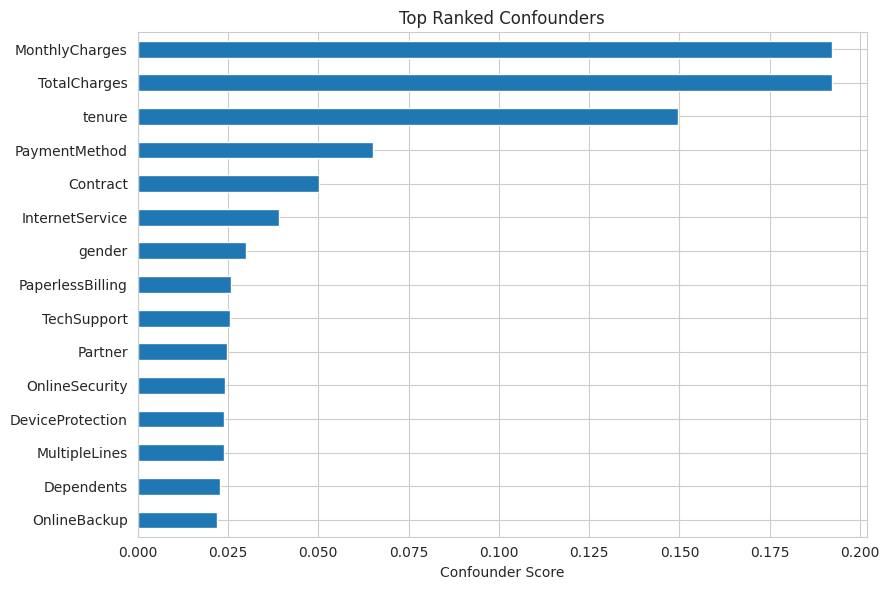

In [ ]:
plt.figure(figsize=(9,6))

importance_df["Confounder_Score"]\
    .head(15)\
    .sort_values()\
    .plot.barh()

plt.xlabel("Confounder Score")
plt.ylabel("")
plt.title("Top Ranked Confounders")

plt.tight_layout()
plt.show()

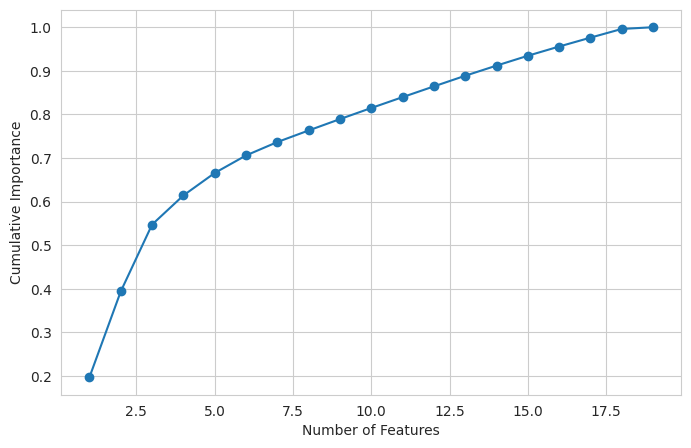

In [ ]:
importance_df["Cumulative"] = (
    importance_df["Confounder_Score"]
    .cumsum()
    / importance_df["Confounder_Score"].sum()
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(importance_df)+1),
    importance_df["Cumulative"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.grid(True)
plt.show()

In [ ]:
TOP_N = 10

selected_features = (
    importance_df
    .head(TOP_N)
    .index
    .tolist()
)

print(selected_features)

X_raw = df[selected_features].copy()

num_cols = [c for c in selected_features if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in selected_features if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X = preprocess.fit_transform(X_raw)

['MonthlyCharges', 'TotalCharges', 'tenure', 'PaymentMethod', 'Contract', 'InternetService', 'gender', 'PaperlessBilling', 'TechSupport', 'Partner']


In [ ]:
rows = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    rows.append({
        "K": k,
        "WCSS": km.inertia_,
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels)
    })

eval_df = pd.DataFrame(rows)
display(eval_df)

,K,WCSS,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,2,36865.434301,0.240762,2489.997543,1.574770
1,3,29558.144102,0.250138,2422.769274,1.464410
2,4,26497.191962,0.218474,2072.557028,1.673445
3,5,24421.477592,0.203552,1835.846090,1.795258
4,6,22749.686885,0.204782,1679.805156,1.742924
5,7,21658.011369,0.187324,1529.299351,1.698539
6,8,20787.166766,0.183634,1407.649851,1.797904
7,9,20068.189567,0.171300,1307.139586,1.875424
8,10,19574.699095,0.172334,1210.728082,1.955008


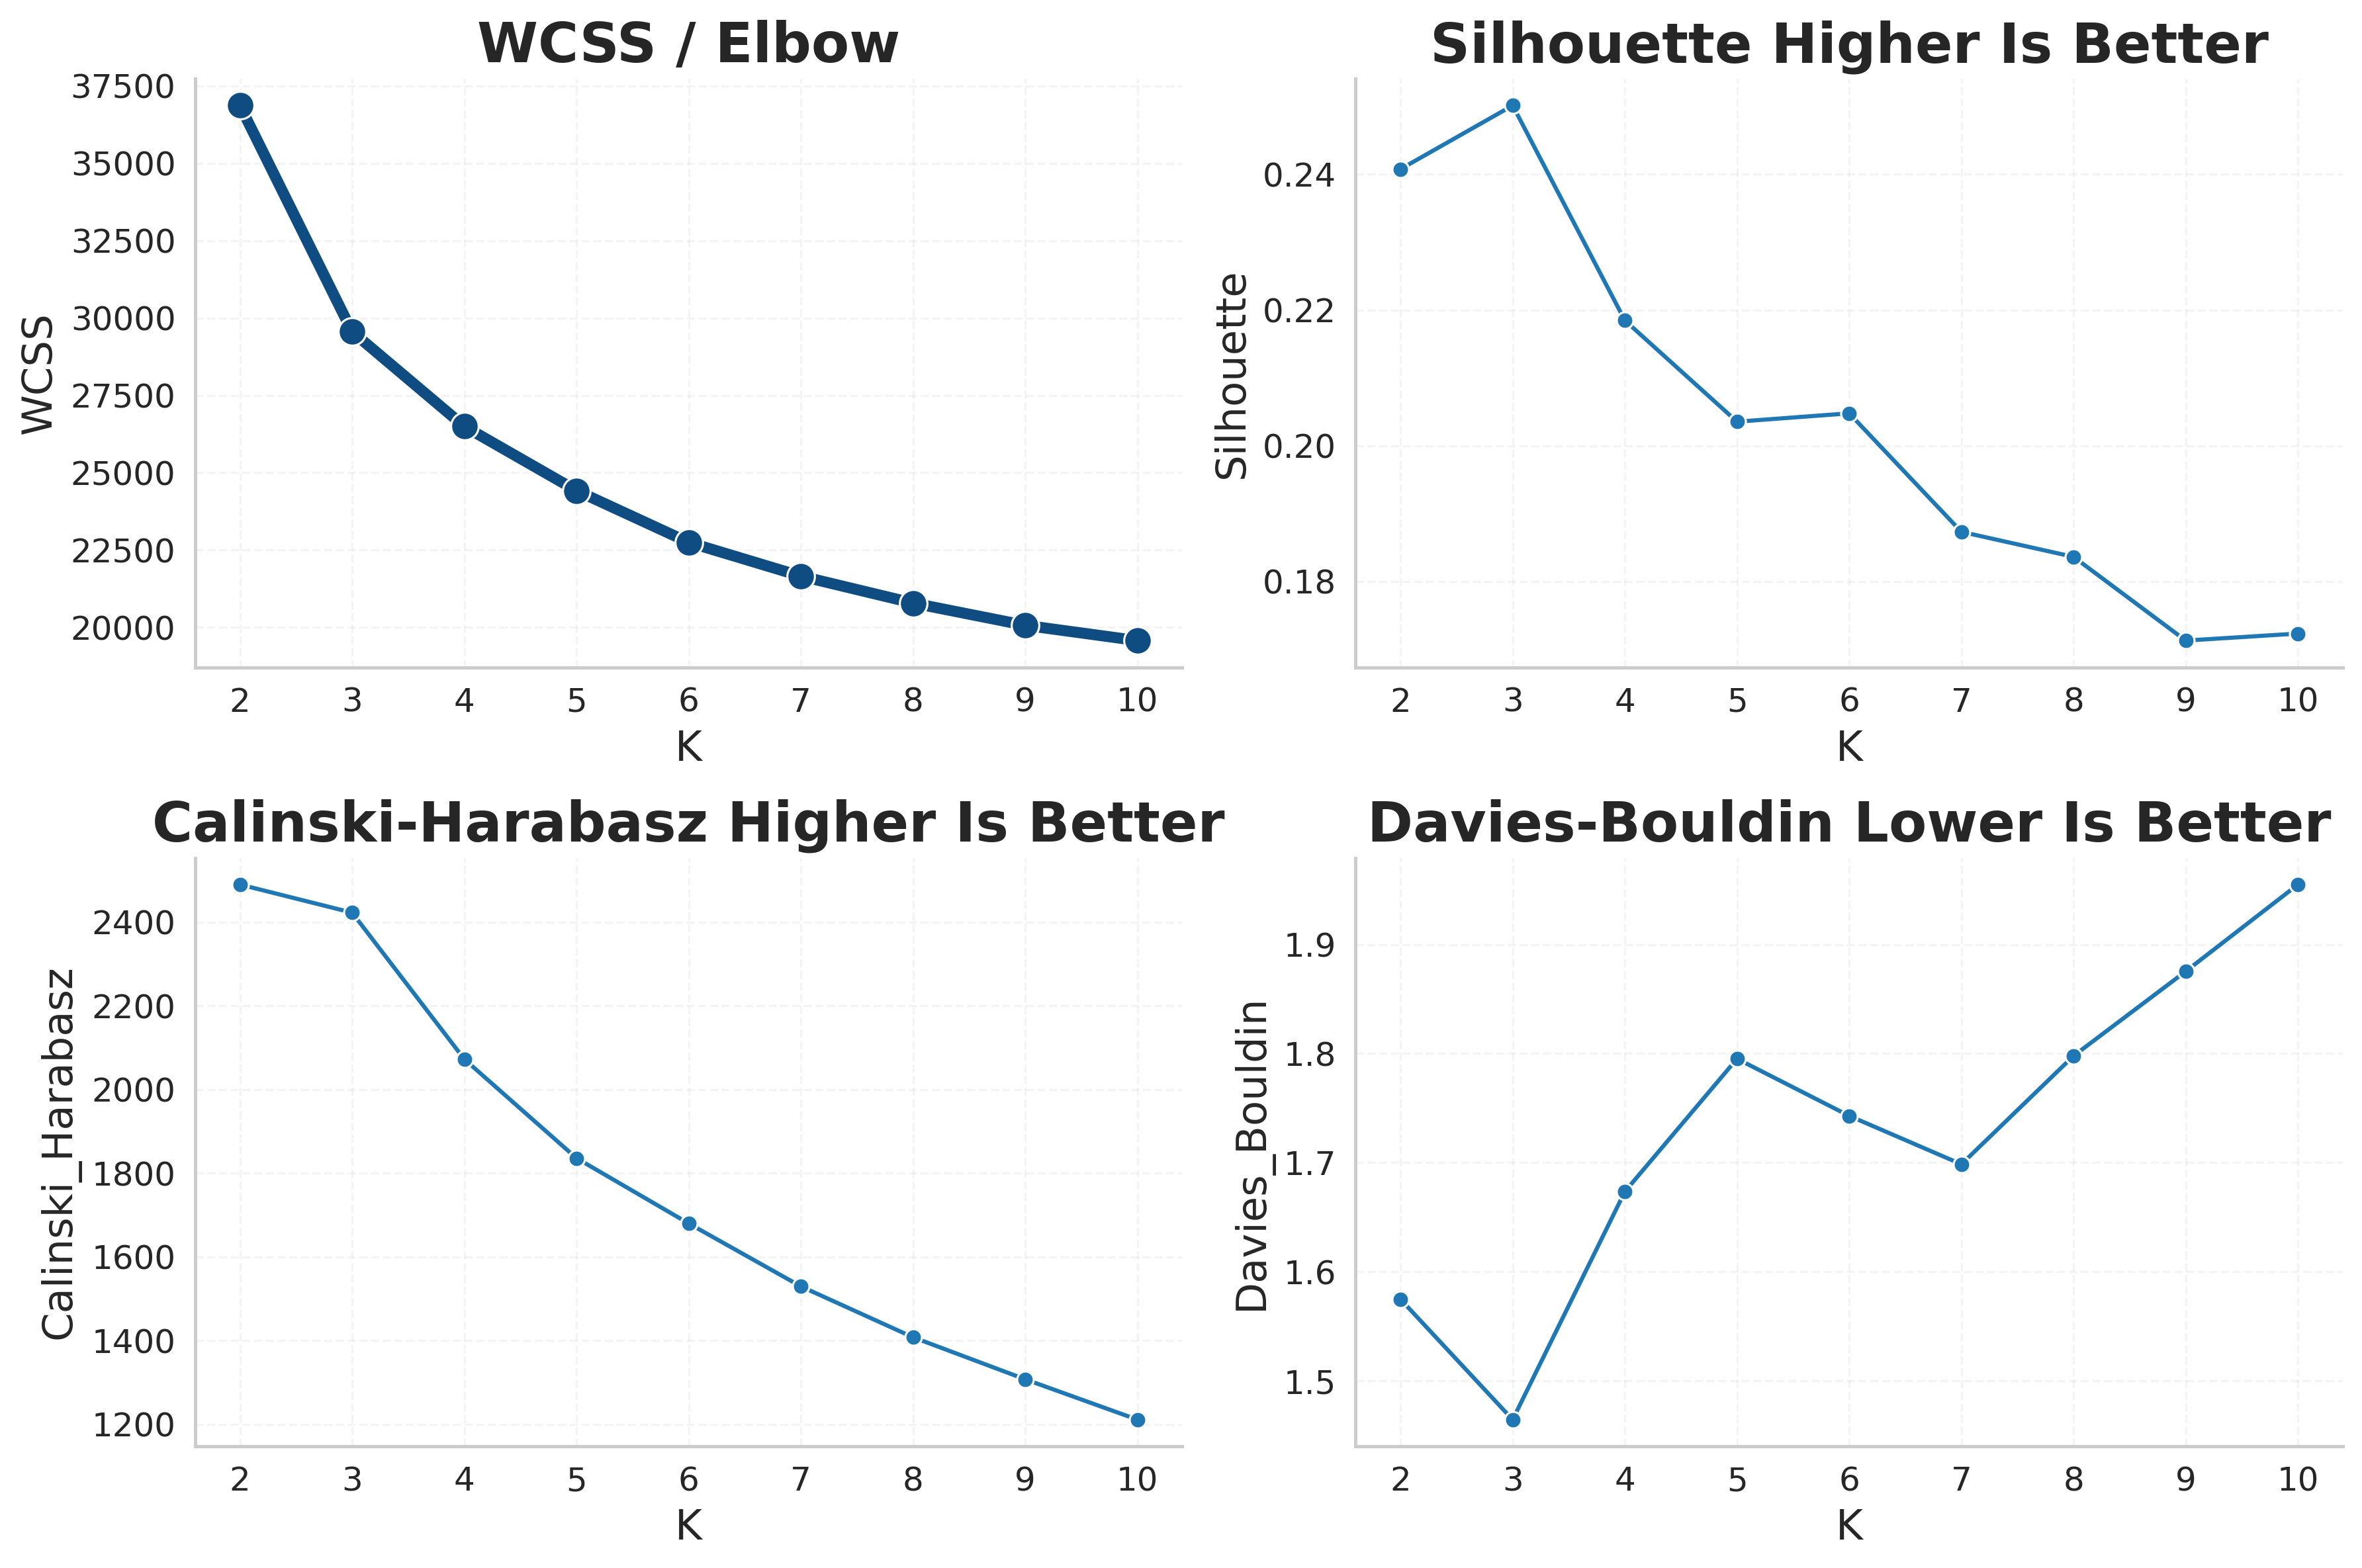

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(data=eval_df, x="K", y="WCSS", marker="o", ax=axes[0, 0],linewidth=4,markersize=10,color="#0F4C81")
axes[0, 0].set_title("WCSS / Elbow")

sns.lineplot(data=eval_df, x="K", y="Silhouette", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Silhouette Higher Is Better")

sns.lineplot(data=eval_df, x="K", y="Calinski_Harabasz", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Calinski-Harabasz Higher Is Better")

sns.lineplot(data=eval_df, x="K", y="Davies_Bouldin", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Davies-Bouldin Lower Is Better")

plt.tight_layout()
plt.show()

In [ ]:
FINAL_K = 3

km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
df["Customer_Segment"] = km.fit_predict(X)

segment_counts = (
    df["Customer_Segment"]
    .value_counts()
    .sort_index()
    .reset_index()
)

segment_counts.columns = ["Customer_Segment", "Customers"]
segment_counts["Percent"] = (segment_counts["Customers"] / len(df) * 100).round(2)

display(segment_counts)

segment_name_map = {
    0: "Growth Customers",
    1: "Budget Stable Customers",
    2: "Premium At-Risk Customers"
}

df["Segment_Name"] = df["Customer_Segment"].map(segment_name_map)

display(
    df[["Customer_Segment", "Segment_Name"]]
    .drop_duplicates()
    .sort_values("Customer_Segment")
)

,Customer_Segment,Customers,Percent
0,0,1593,22.62
1,1,2292,32.54
2,2,3158,44.84


,Customer_Segment,Segment_Name
3,0,Growth Customers
8,1,Budget Stable Customers
0,2,Premium At-Risk Customers


In [ ]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    TREATMENT,
    OUTCOME,
    "SeniorCitizen",
    "Customer_Value",
    "Offer_Cost",
    "Expected_Revenue_Saved",
    "Expected_Net_Value",
    "True_Treatment_Effect"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

summary_rows = []

for seg, g in df.groupby("Customer_Segment"):
    for col in numeric_cols:
        s = g[col].dropna()
        summary_rows.append({
            "Segment": seg,
            "Variable": col,
            "Mean": s.mean(),
            "Median": s.median(),
            "Std": s.std(),
            "Min": s.min(),
            "Max": s.max(),
            "Range": s.max() - s.min()
        })

segment_summary = pd.DataFrame(summary_rows).round(3)

display(segment_summary)

,Segment,Variable,Mean,Median,Std,Min,Max,Range
0,0,tenure,30.838,26.000,24.033,0.000,72.000,72.000
1,0,MonthlyCharges,21.734,20.200,3.930,18.250,50.800,32.550
2,0,TotalCharges,697.597,563.050,571.985,18.800,2424.500,2405.700
3,0,Received_Offer,0.327,0.000,0.469,0.000,1.000,1.000
4,0,Churn_Final_Flag,0.075,0.000,0.264,0.000,1.000,1.000
5,0,SeniorCitizen,0.035,0.000,0.184,0.000,1.000,1.000
6,0,Customer_Value,350.094,350.000,3.758,350.000,500.000,150.000
7,0,Offer_Cost,3.271,0.000,4.693,0.000,10.000,10.000
8,0,Expected_Revenue_Saved,4.240,0.000,8.294,0.000,43.750,43.750
9,0,Expected_Net_Value,0.969,0.000,5.806,-8.250,33.750,42.000


In [ ]:
profile_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    TREATMENT,
    OUTCOME
]

profile_cols = [c for c in profile_cols if c in df.columns]

segment_profile = (
    df
    .groupby("Customer_Segment")[profile_cols]
    .mean()
    .round(3)
)

segment_profile = segment_profile.rename(columns={
    TREATMENT: "Offer_Rate",
    OUTCOME: "Churn_Rate"
})

display(segment_profile)

,tenure,MonthlyCharges,TotalCharges,Offer_Rate,Churn_Rate
Customer_Segment,,,,,
0,30.838,21.734,697.597,0.327,0.075
1,57.977,88.305,5119.813,0.476,0.175
2,14.560,69.379,1021.424,0.744,0.333


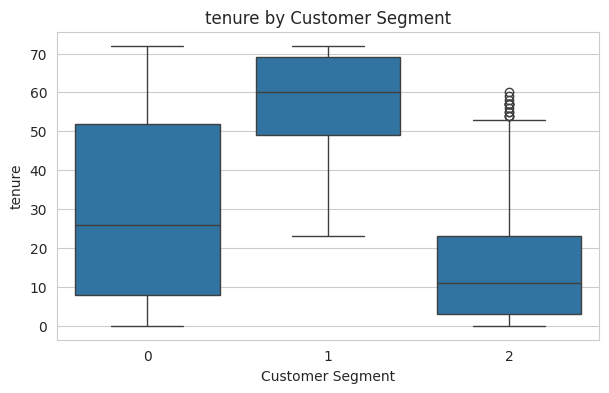

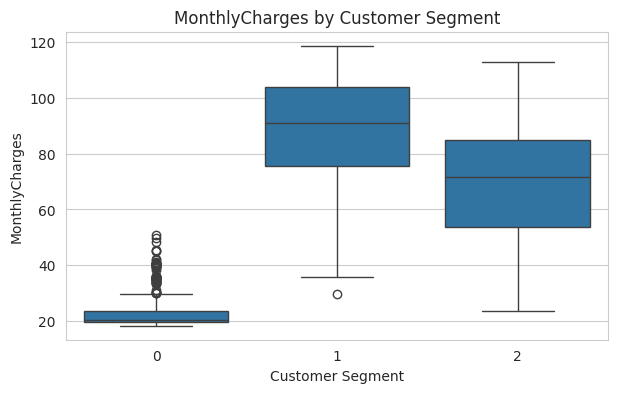

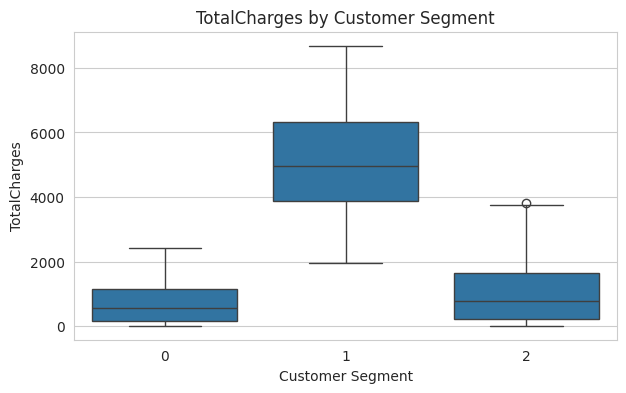

In [ ]:
plot_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plot_cols = [c for c in plot_cols if c in df.columns]

for col in plot_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Customer_Segment", y=col)
    plt.title(f"{col} by Customer Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel(col)
    plt.show()

In [ ]:
rate_profile = (
    df
    .groupby(["Customer_Segment", "Segment_Name"])
    .agg(
        Customers=("Customer_Segment", "size"),
        Offer_Rate=(TREATMENT, "mean"),
        Churn_Rate=(OUTCOME, "mean")
    )
    .reset_index()
)

display(rate_profile.round(3))

,Customer_Segment,Segment_Name,Customers,Offer_Rate,Churn_Rate
0,0,Growth Customers,1593,0.327,0.075
1,1,Budget Stable Customers,2292,0.476,0.175
2,2,Premium At-Risk Customers,3158,0.744,0.333


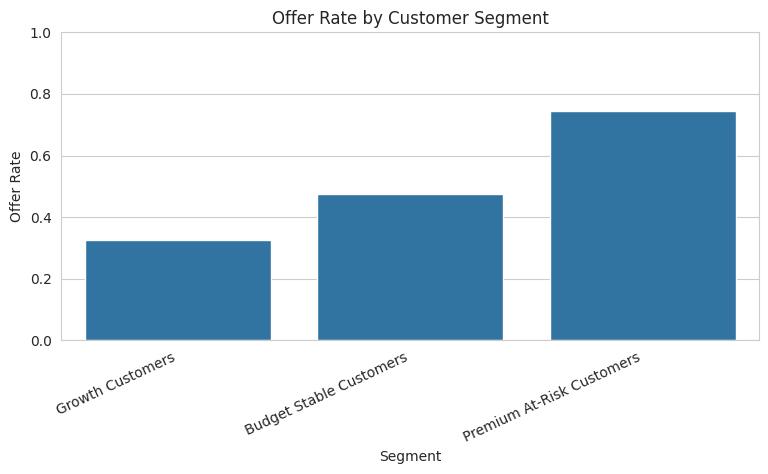

In [ ]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=rate_profile,
    x="Segment_Name",
    y="Offer_Rate"
)

plt.title("Offer Rate by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Offer Rate")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.show()

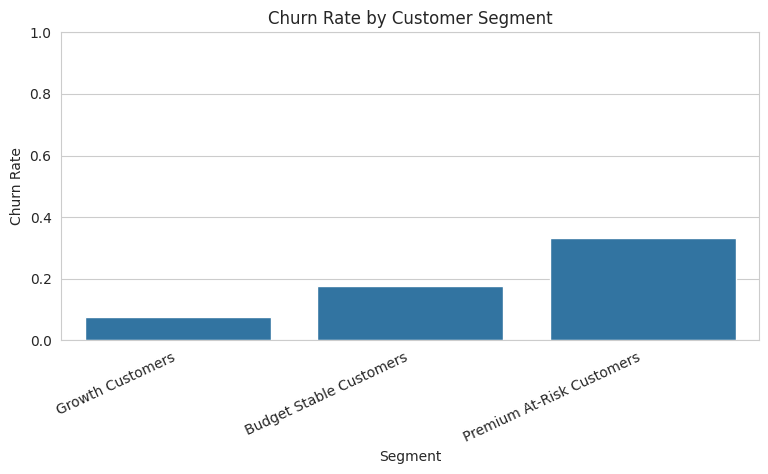

In [ ]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=rate_profile,
    x="Segment_Name",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.show()

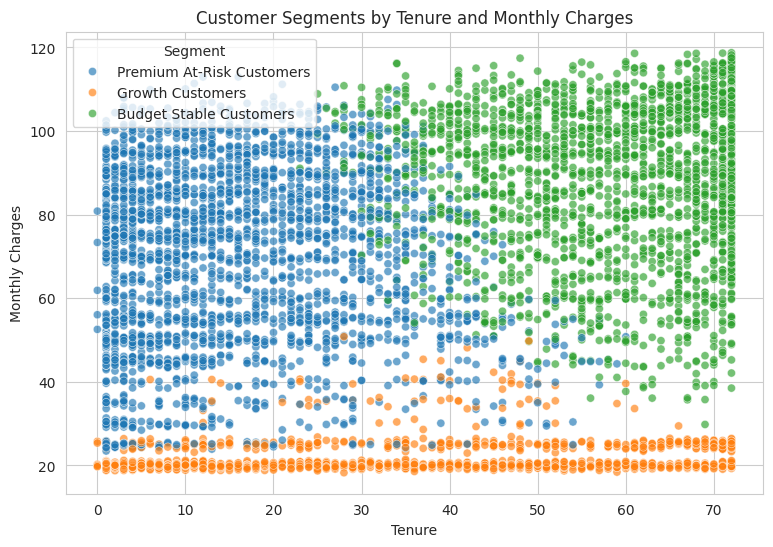

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Segment_Name",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title("Customer Segments by Tenure and Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.legend(title="Segment")
plt.show()

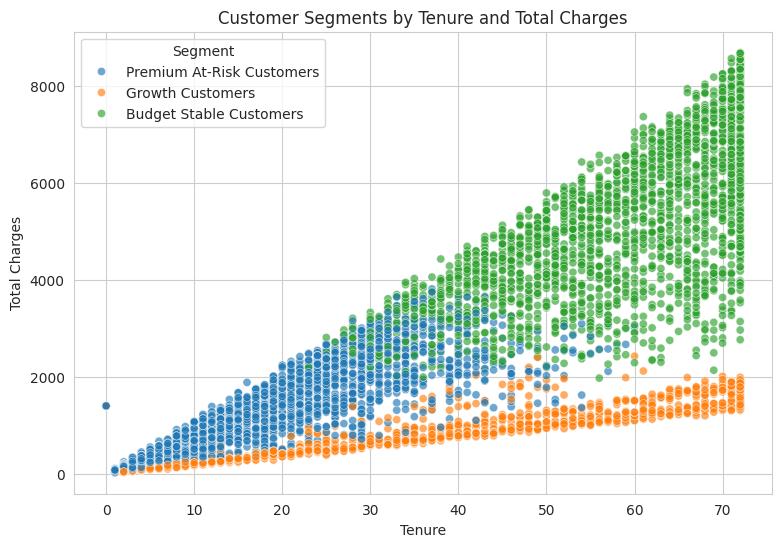

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Segment_Name",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title("Customer Segments by Tenure and Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.legend(title="Segment")
plt.show()

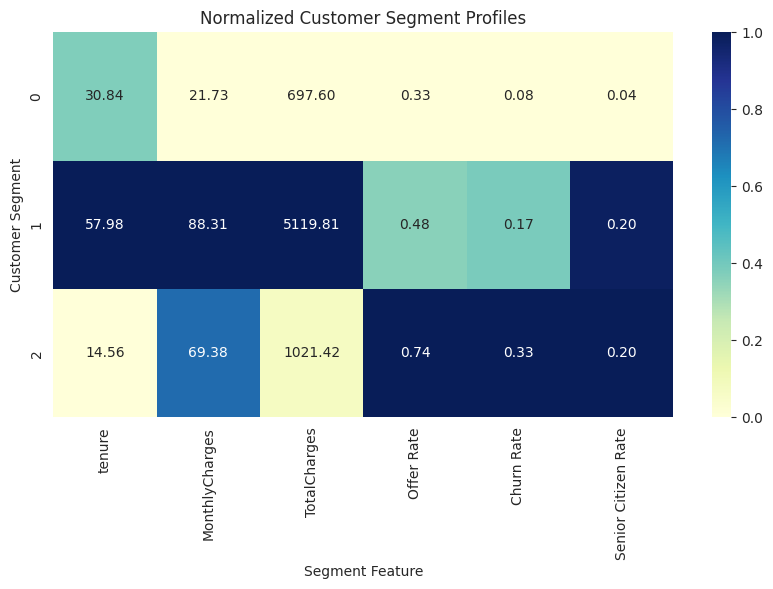

In [ ]:
from sklearn.preprocessing import MinMaxScaler

radar_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    TREATMENT,
    OUTCOME,
    "SeniorCitizen"
]

radar_cols = [c for c in radar_cols if c in df.columns]

segment_profile_for_plot = (
    df
    .groupby("Customer_Segment")[radar_cols]
    .mean()
)

segment_profile_for_plot = segment_profile_for_plot.rename(columns={
    TREATMENT: "Offer Rate",
    OUTCOME: "Churn Rate",
    "SeniorCitizen": "Senior Citizen Rate"
})

scaler = MinMaxScaler()

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(segment_profile_for_plot),
    columns=segment_profile_for_plot.columns,
    index=segment_profile_for_plot.index
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_scaled,
    annot=segment_profile_for_plot.round(2),
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Normalized Customer Segment Profiles")
plt.xlabel("Segment Feature")
plt.ylabel("Customer Segment")
plt.show()

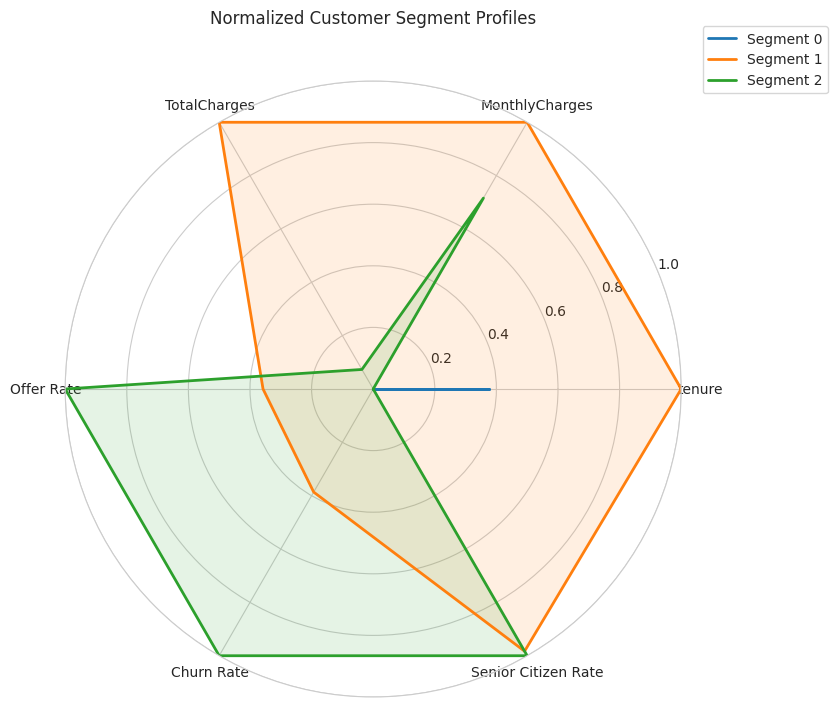

In [ ]:
from sklearn.preprocessing import MinMaxScaler

radar_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    TREATMENT,
    OUTCOME,
    "SeniorCitizen"
]

radar_cols = [c for c in radar_cols if c in df.columns]

radar_profile = (
    df
    .groupby("Customer_Segment")[radar_cols]
    .mean()
)

radar_profile = radar_profile.rename(columns={
    TREATMENT: "Offer Rate",
    OUTCOME: "Churn Rate",
    "SeniorCitizen": "Senior Citizen Rate"
})

scaler = MinMaxScaler()

radar_scaled = pd.DataFrame(
    scaler.fit_transform(radar_profile),
    columns=radar_profile.columns,
    index=radar_profile.index
)

labels = radar_scaled.columns.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for seg in radar_scaled.index:
    values = radar_scaled.loc[seg].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Segment {seg}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.12
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

plt.title("Normalized Customer Segment Profiles", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.show()

In [ ]:
causal_df = df[[TREATMENT, OUTCOME, "Customer_Segment"] + BASELINE_COLS].copy()

for c in BASELINE_COLS:
    if pd.api.types.is_numeric_dtype(causal_df[c]):
        causal_df[c] = pd.to_numeric(causal_df[c], errors="coerce").fillna(causal_df[c].median())
    else:
        causal_df[c] = causal_df[c].fillna("Missing").astype(str)

causal_df = pd.get_dummies(
    causal_df,
    columns=[c for c in BASELINE_COLS if not pd.api.types.is_numeric_dtype(df[c])],
    drop_first=True,
    dtype=float
)

causal_df[TREATMENT] = causal_df[TREATMENT].astype(int)
causal_df[OUTCOME] = causal_df[OUTCOME].astype(int)
causal_df["Customer_Segment"] = causal_df["Customer_Segment"].astype(int)

confounders = [
    c for c in causal_df.columns
    if c not in [TREATMENT, OUTCOME, "Customer_Segment"]
]

print("Causal data shape:", causal_df.shape)
print("Number of confounders:", len(confounders))

Causal data shape: (7043, 33)
Number of confounders: 30


In [ ]:
results = []

for seg in sorted(causal_df["Customer_Segment"].unique()):
    seg_df = causal_df[causal_df["Customer_Segment"] == seg].copy()

    n = len(seg_df)
    treated = seg_df[TREATMENT].sum()
    control = n - treated

    print("\n" + "=" * 70)
    print(f"Segment {seg} | N={n} | Treated={treated} | Control={control}")
    print("=" * 70)

    if treated < 20 or control < 20:
        print("Skipped: not enough treated/control customers.")
        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Naive_Diff": np.nan,
            "DoWhy_Effect": np.nan,
            "Status": "Skipped"
        })
        continue

    naive_treated = seg_df.loc[seg_df[TREATMENT] == 1, OUTCOME].mean()
    naive_control = seg_df.loc[seg_df[TREATMENT] == 0, OUTCOME].mean()
    naive_diff = naive_treated - naive_control

    try:
        model = CausalModel(
            data=seg_df,
            treatment=TREATMENT,
            outcome=OUTCOME,
            common_causes=confounders
        )

        estimand = model.identify_effect(proceed_when_unidentifiable=True)

        estimate = model.estimate_effect(
            estimand,
            method_name="backdoor.linear_regression"
        )

        refute = model.refute_estimate(
            estimand,
            estimate,
            method_name="random_common_cause"
        )

        print("Naive difference:", round(naive_diff, 4))
        print("DoWhy adjusted effect:", round(estimate.value, 4))
        print(refute)

        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Churn_Treated": naive_treated,
            "Churn_Control": naive_control,
            "Naive_Diff": naive_diff,
            "DoWhy_Effect": estimate.value,
            "Refuted_Effect": getattr(refute, "new_effect", np.nan),
            "Status": "Success"
        })

    except Exception as e:
        print("Failed:", e)
        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Naive_Diff": naive_diff,
            "DoWhy_Effect": np.nan,
            "Status": "Failed"
        })

dowhy_results = pd.DataFrame(results).round(4)
display(dowhy_results)


Segment 0 | N=1593 | Treated=521 | Control=1072


Naive difference: 0.0364
DoWhy adjusted effect: -0.0122
Refute: Add a random common cause
Estimated effect:-0.012161112425539161
New effect:-0.012148048395221444
p value:0.9


Segment 1 | N=2292 | Treated=1091 | Control=1201


Naive difference: 0.0352
DoWhy adjusted effect: -0.0676
Refute: Add a random common cause
Estimated effect:-0.06762826467832167
New effect:-0.06765574529363581
p value:0.92


Segment 2 | N=3158 | Treated=2348 | Control=810


Naive difference: 0.0529
DoWhy adjusted effect: -0.1477
Refute: Add a random common cause
Estimated effect:-0.14772710542034478
New effect:-0.14772183918810444
p value:0.94



,Segment,N,Treated,Control,Churn_Treated,Churn_Control,Naive_Diff,DoWhy_Effect,Refuted_Effect,Status
0,0,1593,521,1072,0.0998,0.0634,0.0364,-0.0122,-0.0121,Success
1,1,2292,1091,1201,0.1934,0.1582,0.0352,-0.0676,-0.0677,Success
2,2,3158,2348,810,0.3467,0.2938,0.0529,-0.1477,-0.1477,Success


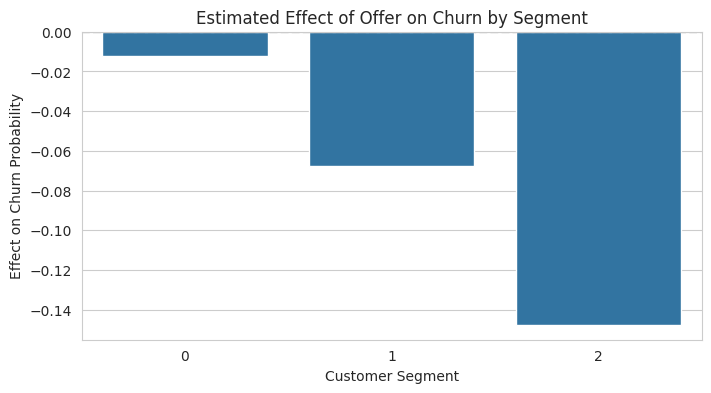

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=dowhy_results,
    x="Segment",
    y="DoWhy_Effect"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Estimated Effect of Offer on Churn by Segment")
plt.ylabel("Effect on Churn Probability")
plt.xlabel("Customer Segment")
plt.show()

In [ ]:
final_report = (
    segment_counts
    .merge(segment_profile.reset_index(), on="Customer_Segment", how="left")
    .merge(dowhy_results, left_on="Customer_Segment", right_on="Segment", how="left")
)

display(final_report)

,Customer_Segment,Customers,Percent,tenure,MonthlyCharges,TotalCharges,Offer_Rate,Churn_Rate,Segment,N,Treated,Control,Churn_Treated,Churn_Control,Naive_Diff,DoWhy_Effect,Refuted_Effect,Status
0,0,1593,22.62,30.838,21.734,697.597,0.327,0.075,0,1593,521,1072,0.0998,0.0634,0.0364,-0.0122,-0.0121,Success
1,1,2292,32.54,57.977,88.305,5119.813,0.476,0.175,1,2292,1091,1201,0.1934,0.1582,0.0352,-0.0676,-0.0677,Success
2,2,3158,44.84,14.560,69.379,1021.424,0.744,0.333,2,3158,2348,810,0.3467,0.2938,0.0529,-0.1477,-0.1477,Success


In [ ]:
roi_rows = []

for seg in sorted(df["Customer_Segment"].unique()):
    seg_df = df[df["Customer_Segment"] == seg].copy()
    treated_df = seg_df[seg_df[TREATMENT] == 1].copy()

    seg_name = segment_name_map.get(seg, f"Segment {seg}")

    n_customers = len(seg_df)
    n_treated = len(treated_df)

    dowhy_effect = dowhy_results.loc[
        dowhy_results["Segment"] == seg,
        "DoWhy_Effect"
    ].values

    dowhy_effect = dowhy_effect[0] if len(dowhy_effect) > 0 else np.nan

    # Negative treatment effect means churn reduction.
    estimated_churn_reduction_rate = max(-dowhy_effect, 0) if pd.notna(dowhy_effect) else np.nan

    estimated_churns_prevented = (
        estimated_churn_reduction_rate * n_treated
        if pd.notna(estimated_churn_reduction_rate)
        else np.nan
    )

    avg_customer_value = (
        treated_df["Customer_Value"].mean()
        if "Customer_Value" in treated_df.columns
        else np.nan
    )

    total_offer_cost = (
        treated_df["Offer_Cost"].sum()
        if "Offer_Cost" in treated_df.columns
        else np.nan
    )

    estimated_revenue_saved = (
        estimated_churns_prevented * avg_customer_value
        if pd.notna(estimated_churns_prevented) and pd.notna(avg_customer_value)
        else np.nan
    )

    estimated_net_value = (
        estimated_revenue_saved - total_offer_cost
        if pd.notna(estimated_revenue_saved) and pd.notna(total_offer_cost)
        else np.nan
    )

    estimated_roi = (
        estimated_net_value / total_offer_cost
        if pd.notna(estimated_net_value) and pd.notna(total_offer_cost) and total_offer_cost != 0
        else np.nan
    )

    row = {
        "Customer_Segment": seg,
        "Segment_Name": seg_name,
        "Customers": n_customers,
        "Treated_Customers": n_treated,
        "Offer_Rate": n_treated / n_customers if n_customers > 0 else np.nan,
        "Churn_Rate": seg_df[OUTCOME].mean(),
        "DoWhy_Effect": dowhy_effect,
        "Estimated_Churn_Reduction_Rate": estimated_churn_reduction_rate,
        "Estimated_Churns_Prevented": estimated_churns_prevented,
        "Avg_Customer_Value_Treated": avg_customer_value,
        "Total_Offer_Cost": total_offer_cost,
        "Estimated_Revenue_Saved": estimated_revenue_saved,
        "Estimated_Net_Value": estimated_net_value,
        "Estimated_ROI": estimated_roi
    }

    if "Expected_Revenue_Saved" in treated_df.columns:
        row["Simulated_Expected_Revenue_Saved"] = treated_df["Expected_Revenue_Saved"].sum()

    if "Expected_Net_Value" in treated_df.columns:
        row["Simulated_Expected_Net_Value"] = treated_df["Expected_Net_Value"].sum()

    roi_rows.append(row)

segment_roi = pd.DataFrame(roi_rows)

money_cols = [
    "Avg_Customer_Value_Treated",
    "Total_Offer_Cost",
    "Estimated_Revenue_Saved",
    "Estimated_Net_Value",
    "Simulated_Expected_Revenue_Saved",
    "Simulated_Expected_Net_Value"
]

for c in money_cols:
    if c in segment_roi.columns:
        segment_roi[c] = segment_roi[c].round(2)

rate_cols = [
    "Offer_Rate",
    "Churn_Rate",
    "DoWhy_Effect",
    "Estimated_Churn_Reduction_Rate",
    "Estimated_ROI"
]

for c in rate_cols:
    if c in segment_roi.columns:
        segment_roi[c] = segment_roi[c].round(4)

segment_roi["Estimated_Churns_Prevented"] = segment_roi["Estimated_Churns_Prevented"].round(2)

display(segment_roi)

,Customer_Segment,Segment_Name,Customers,Treated_Customers,Offer_Rate,Churn_Rate,DoWhy_Effect,Estimated_Churn_Reduction_Rate,Estimated_Churns_Prevented,Avg_Customer_Value_Treated,Total_Offer_Cost,Estimated_Revenue_Saved,Estimated_Net_Value,Estimated_ROI,Simulated_Expected_Revenue_Saved,Simulated_Expected_Net_Value
0,0,Growth Customers,1593,521,0.3271,0.0753,-0.0122,0.0122,6.36,350.00,5210.0,2224.67,-2985.33,-0.5730,6754.37,1544.37
1,1,Budget Stable Customers,2292,1091,0.4760,0.1750,-0.0676,0.0676,73.75,619.75,10910.0,45707.74,34797.74,3.1895,75039.82,64129.82
2,2,Premium At-Risk Customers,3158,2348,0.7435,0.3331,-0.1477,0.1477,346.80,537.05,23480.0,186249.70,162769.70,6.9323,265818.50,242338.50


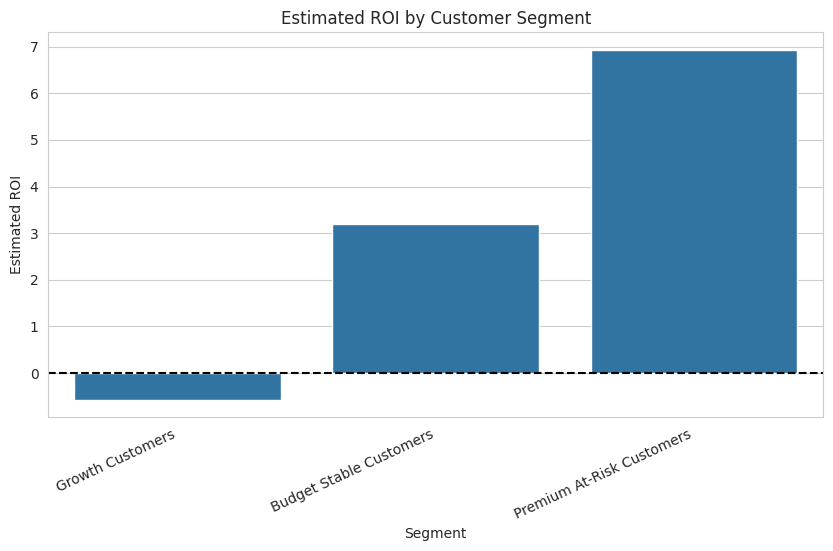

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_roi,
    x="Segment_Name",
    y="Estimated_ROI"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Estimated ROI by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Estimated ROI")
plt.xticks(rotation=25, ha="right")
plt.show()

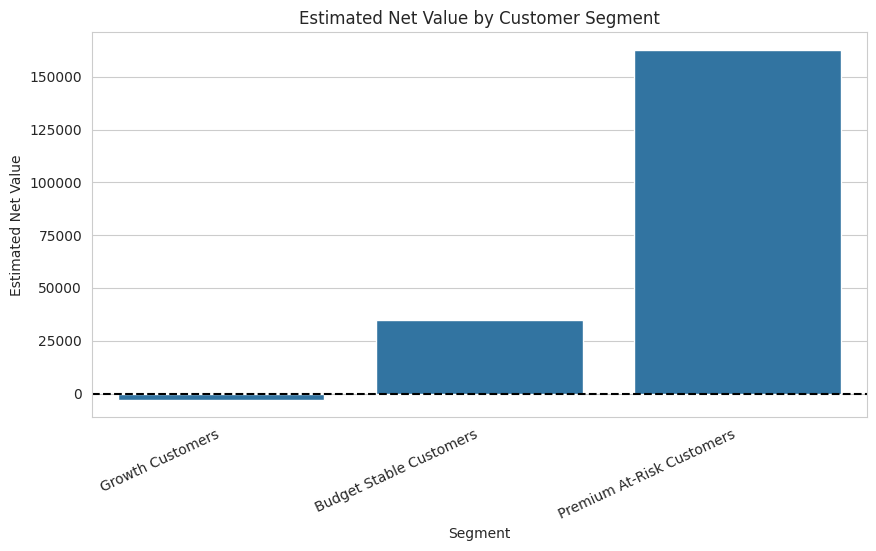

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_roi,
    x="Segment_Name",
    y="Estimated_Net_Value"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Estimated Net Value by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Estimated Net Value")
plt.xticks(rotation=25, ha="right")
plt.show()

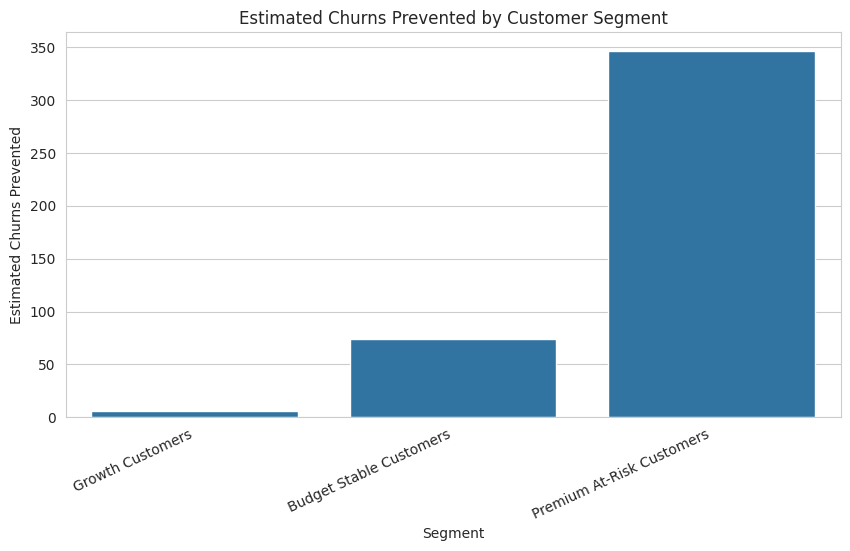

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_roi,
    x="Segment_Name",
    y="Estimated_Churns_Prevented"
)

plt.title("Estimated Churns Prevented by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Estimated Churns Prevented")
plt.xticks(rotation=25, ha="right")
plt.show()

In [ ]:
roi_recommendation = (
    segment_roi
    .sort_values("Estimated_ROI", ascending=False)
    .reset_index(drop=True)
)

display(roi_recommendation)

,Customer_Segment,Segment_Name,Customers,Treated_Customers,Offer_Rate,Churn_Rate,DoWhy_Effect,Estimated_Churn_Reduction_Rate,Estimated_Churns_Prevented,Avg_Customer_Value_Treated,Total_Offer_Cost,Estimated_Revenue_Saved,Estimated_Net_Value,Estimated_ROI,Simulated_Expected_Revenue_Saved,Simulated_Expected_Net_Value
0,2,Premium At-Risk Customers,3158,2348,0.7435,0.3331,-0.1477,0.1477,346.80,537.05,23480.0,186249.70,162769.70,6.9323,265818.50,242338.50
1,1,Budget Stable Customers,2292,1091,0.4760,0.1750,-0.0676,0.0676,73.75,619.75,10910.0,45707.74,34797.74,3.1895,75039.82,64129.82
2,0,Growth Customers,1593,521,0.3271,0.0753,-0.0122,0.0122,6.36,350.00,5210.0,2224.67,-2985.33,-0.5730,6754.37,1544.37


In [ ]:
truth_cols = [
    "True_Propensity",
    "Churn_Probability_No_Offer",
    "Churn_Probability_With_Offer",
    "True_Treatment_Effect"
]

truth_cols = [c for c in truth_cols if c in df.columns]

if truth_cols:
    truth_check = (
        df
        .groupby("Customer_Segment")[truth_cols]
        .mean()
        .round(4)
    )

    display(truth_check)

,True_Propensity,Churn_Probability_No_Offer,Churn_Probability_With_Offer,True_Treatment_Effect
Customer_Segment,,,,
0,0.3033,0.0772,0.0518,-0.0253
1,0.4840,0.2278,0.1605,-0.0673
2,0.7407,0.4749,0.3009,-0.1740


In [ ]:
# ============================================
# Overall Causal Effect (Entire Dataset)
# ============================================

overall_df = causal_df.copy()

naive_treated = overall_df.loc[
    overall_df[TREATMENT] == 1,
    OUTCOME
].mean()

naive_control = overall_df.loc[
    overall_df[TREATMENT] == 0,
    OUTCOME
].mean()

naive_diff = naive_treated - naive_control

model = CausalModel(
    data=overall_df,
    treatment=TREATMENT,
    outcome=OUTCOME,
    common_causes=confounders
)

estimand = model.identify_effect(
    proceed_when_unidentifiable=True
)

estimate = model.estimate_effect(
    estimand,
    method_name="backdoor.linear_regression"
)

refute = model.refute_estimate(
    estimand,
    estimate,
    method_name="random_common_cause"
)

overall_results = pd.DataFrame({
    "Metric":[
        "Naive Churn (Offer)",
        "Naive Churn (No Offer)",
        "Naive Difference",
        "DoWhy Effect",
        "Refuted Effect",
        "Refutation p-value"
    ],
    "Value":[
        naive_treated,
        naive_control,
        naive_diff,
        estimate.value,
        refute.new_effect,
        refute.refutation_result["p_value"]
        if hasattr(refute,"refutation_result")
        else np.nan
    ]
})

display(overall_results.round(4))

,Metric,Value
0,Naive Churn (Offer),0.2720
1,Naive Churn (No Offer),0.1609
2,Naive Difference,0.1111
3,DoWhy Effect,-0.0826
4,Refuted Effect,-0.0827
5,Refutation p-value,1.0000


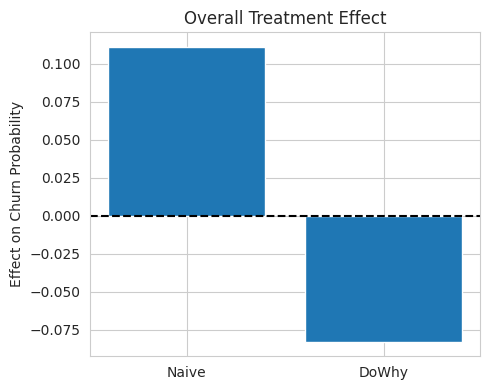

In [ ]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Naive","DoWhy"],
    [naive_diff, estimate.value]
)

plt.axhline(0,color="black",linestyle="--")

plt.ylabel("Effect on Churn Probability")
plt.title("Overall Treatment Effect")

plt.tight_layout()
plt.show()

In [ ]:
segment_results = dowhy_results[[
    "Segment",
    "N",
    "Churn_Treated",
    "Churn_Control",
    "Naive_Diff",
    "DoWhy_Effect"
]].copy()

display(segment_results.round(4))

,Segment,N,Churn_Treated,Churn_Control,Naive_Diff,DoWhy_Effect
0,0,1593,0.0998,0.0634,0.0364,-0.0122
1,1,2292,0.1934,0.1582,0.0352,-0.0676
2,2,3158,0.3467,0.2938,0.0529,-0.1477


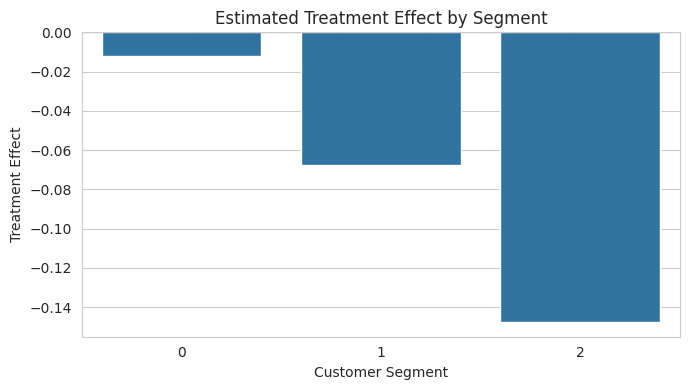

In [ ]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=segment_results,
    x="Segment",
    y="DoWhy_Effect"
)

plt.axhline(0,color="black",linestyle="--")

plt.ylabel("Treatment Effect")
plt.xlabel("Customer Segment")
plt.title("Estimated Treatment Effect by Segment")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Executive Summary
# ==========================================

executive_summary = (
    segment_counts
    .merge(
        segment_profile.reset_index(),
        on="Customer_Segment",
        how="left"
    )
    .merge(
        dowhy_results[["Segment","DoWhy_Effect"]],
        left_on="Customer_Segment",
        right_on="Segment",
        how="left"
    )
)

# Add readable names
executive_summary["Segment_Name"] = executive_summary["Customer_Segment"].map(segment_name_map)

executive_summary = executive_summary[
    [
        "Segment_Name",
        "Customers",
        "Percent",
        "Offer_Rate",
        "Churn_Rate",
        "DoWhy_Effect"
    ]
]

display(executive_summary.round(3))

,Segment_Name,Customers,Percent,Offer_Rate,Churn_Rate,DoWhy_Effect
0,Growth Customers,1593,22.62,0.327,0.075,-0.012
1,Budget Stable Customers,2292,32.54,0.476,0.175,-0.068
2,Premium At-Risk Customers,3158,44.84,0.744,0.333,-0.148


In [ ]:
roi_summary = segment_roi[
    [
        "Segment_Name",
        "Customers",
        "Offer_Rate",
        "Churn_Rate",
        "Estimated_Churns_Prevented",
        "Estimated_Revenue_Saved",
        "Estimated_Net_Value",
        "Estimated_ROI"
    ]
]

display(roi_summary)

,Segment_Name,Customers,Offer_Rate,Churn_Rate,Estimated_Churns_Prevented,Estimated_Revenue_Saved,Estimated_Net_Value,Estimated_ROI
0,Growth Customers,1593,0.3271,0.0753,6.36,2224.67,-2985.33,-0.5730
1,Budget Stable Customers,2292,0.4760,0.1750,73.75,45707.74,34797.74,3.1895
2,Premium At-Risk Customers,3158,0.7435,0.3331,346.80,186249.70,162769.70,6.9323


In [ ]:
# ==========================================================
# Overall Causal Estimates
# Naive, PSM, IPW, Doubly Robust
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# ----------------------------
# Data
# ----------------------------

X = causal_df[confounders]
T = causal_df[TREATMENT].values
Y = causal_df[OUTCOME].values

# ----------------------------
# Propensity Scores
# ----------------------------

ps_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

ps_model.fit(X, T)

propensity = ps_model.predict_proba(X)[:,1]

# avoid extreme values
propensity = np.clip(propensity,0.01,0.99)

# ==========================================================
# 1. Naive Effect
# ==========================================================

naive_effect = (
    Y[T==1].mean()
    -
    Y[T==0].mean()
)

# ==========================================================
# 2. Propensity Score Matching (ATT)
# ==========================================================

treated_idx = np.where(T==1)[0]
control_idx = np.where(T==0)[0]

treated_ps = propensity[treated_idx].reshape(-1,1)
control_ps = propensity[control_idx].reshape(-1,1)

nn = NearestNeighbors(n_neighbors=1)

nn.fit(control_ps)

_, matched = nn.kneighbors(treated_ps)

matched_control = control_idx[matched.flatten()]

psm_effect = np.mean(
    Y[treated_idx]
    -
    Y[matched_control]
)

# ==========================================================
# 3. IPW ATE
# ==========================================================

weights = np.where(
    T==1,
    1/propensity,
    1/(1-propensity)
)

ipw_effect = (
    np.sum(weights*T*Y)/np.sum(weights*T)
    -
    np.sum(weights*(1-T)*Y)/np.sum(weights*(1-T))
)

# ==========================================================
# 4. Doubly Robust
# ==========================================================

rf_treated = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_control = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_treated.fit(X[T==1],Y[T==1])
rf_control.fit(X[T==0],Y[T==0])

mu1 = rf_treated.predict(X)
mu0 = rf_control.predict(X)

dr_scores = (
    mu1
    -
    mu0
    +
    T*(Y-mu1)/propensity
    -
    (1-T)*(Y-mu0)/(1-propensity)
)

dr_effect = dr_scores.mean()

# ==========================================================
# Summary
# ==========================================================

overall_methods = pd.DataFrame({
    "Method":[
        "Naive",
        "PSM",
        "IPW",
        "Doubly Robust"
    ],
    "Estimated Effect":[
        naive_effect,
        psm_effect,
        ipw_effect,
        dr_effect
    ]
})

display(overall_methods.round(4))

,Method,Estimated Effect
0,Naive,0.1111
1,PSM,-0.1482
2,IPW,-0.1011
3,Doubly Robust,-0.0899


In [ ]:
comparison = overall_methods.copy()

comparison.loc[len(comparison)] = [
    "DoWhy",
    estimate.value
]

display(comparison.round(4))

,Method,Estimated Effect
0,Naive,0.1111
1,PSM,-0.1482
2,IPW,-0.1011
3,Doubly Robust,-0.0899
4,DoWhy,-0.0826


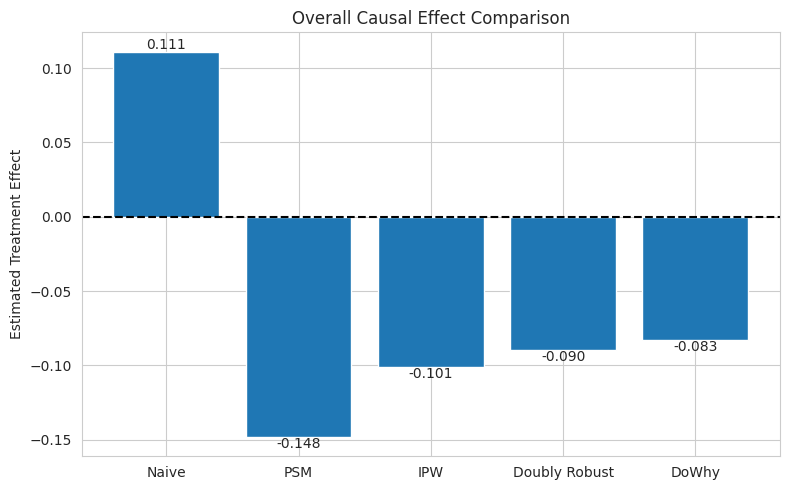

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Method"],
    comparison["Estimated Effect"]
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.ylabel("Estimated Treatment Effect")
plt.title("Overall Causal Effect Comparison")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom" if h>=0 else "top"
    )

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# -----------------------------
# Global Plot Theme
# -----------------------------

plt.style.use("default")

sns.set_style("whitegrid", {
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.20
})

mpl.rcParams.update({

    "figure.figsize": (10,6),
    "figure.dpi": 300,
    "savefig.dpi": 300,

    "font.family":"DejaVu Sans",

    "axes.titlesize":20,
    "axes.titleweight":"bold",

    "axes.labelsize":15,

    "xtick.labelsize":12,
    "ytick.labelsize":12,

    "legend.fontsize":12,

    "axes.spines.top":False,
    "axes.spines.right":False,

    "axes.linewidth":1.2,

    "grid.alpha":0.20,

    "savefig.bbox":"tight",

    "figure.facecolor":"white",
    "axes.facecolor":"white"
})

In [ ]:
print("\n=== importance_df ===")
print(importance_df.head())
print(importance_df.columns)

print("\n=== segment_results ===")
print(segment_results.head())
print(segment_results.columns)

print("\n=== comparison ===")
print(comparison.head())
print(comparison.columns)

print("\n=== segment_profile ===")
print(segment_profile.head())
print(segment_profile.columns)

print("\n=== segment_counts ===")
print(segment_counts.head())
print(segment_counts.columns)


=== importance_df ===
                Treatment   Outcome  Confounder_Score  Cumulative
Feature                                                          
MonthlyCharges   0.178550  0.208089          0.192191    0.196951
TotalCharges     0.178562  0.207940          0.192135    0.393845
tenure           0.150071  0.149291          0.149680    0.547232
PaymentMethod    0.072693  0.059082          0.065184    0.614031
Contract         0.097825  0.033862          0.050309    0.665586
Index(['Treatment', 'Outcome', 'Confounder_Score', 'Cumulative'], dtype='object')

=== segment_results ===
   Segment     N  Churn_Treated  Churn_Control  Naive_Diff  DoWhy_Effect
0        0  1593         0.0998         0.0634      0.0364       -0.0122
1        1  2292         0.1934         0.1582      0.0352       -0.0676
2        2  3158         0.3467         0.2938      0.0529       -0.1477
Index(['Segment', 'N', 'Churn_Treated', 'Churn_Control', 'Naive_Diff',
       'DoWhy_Effect'],
      dtype='object')

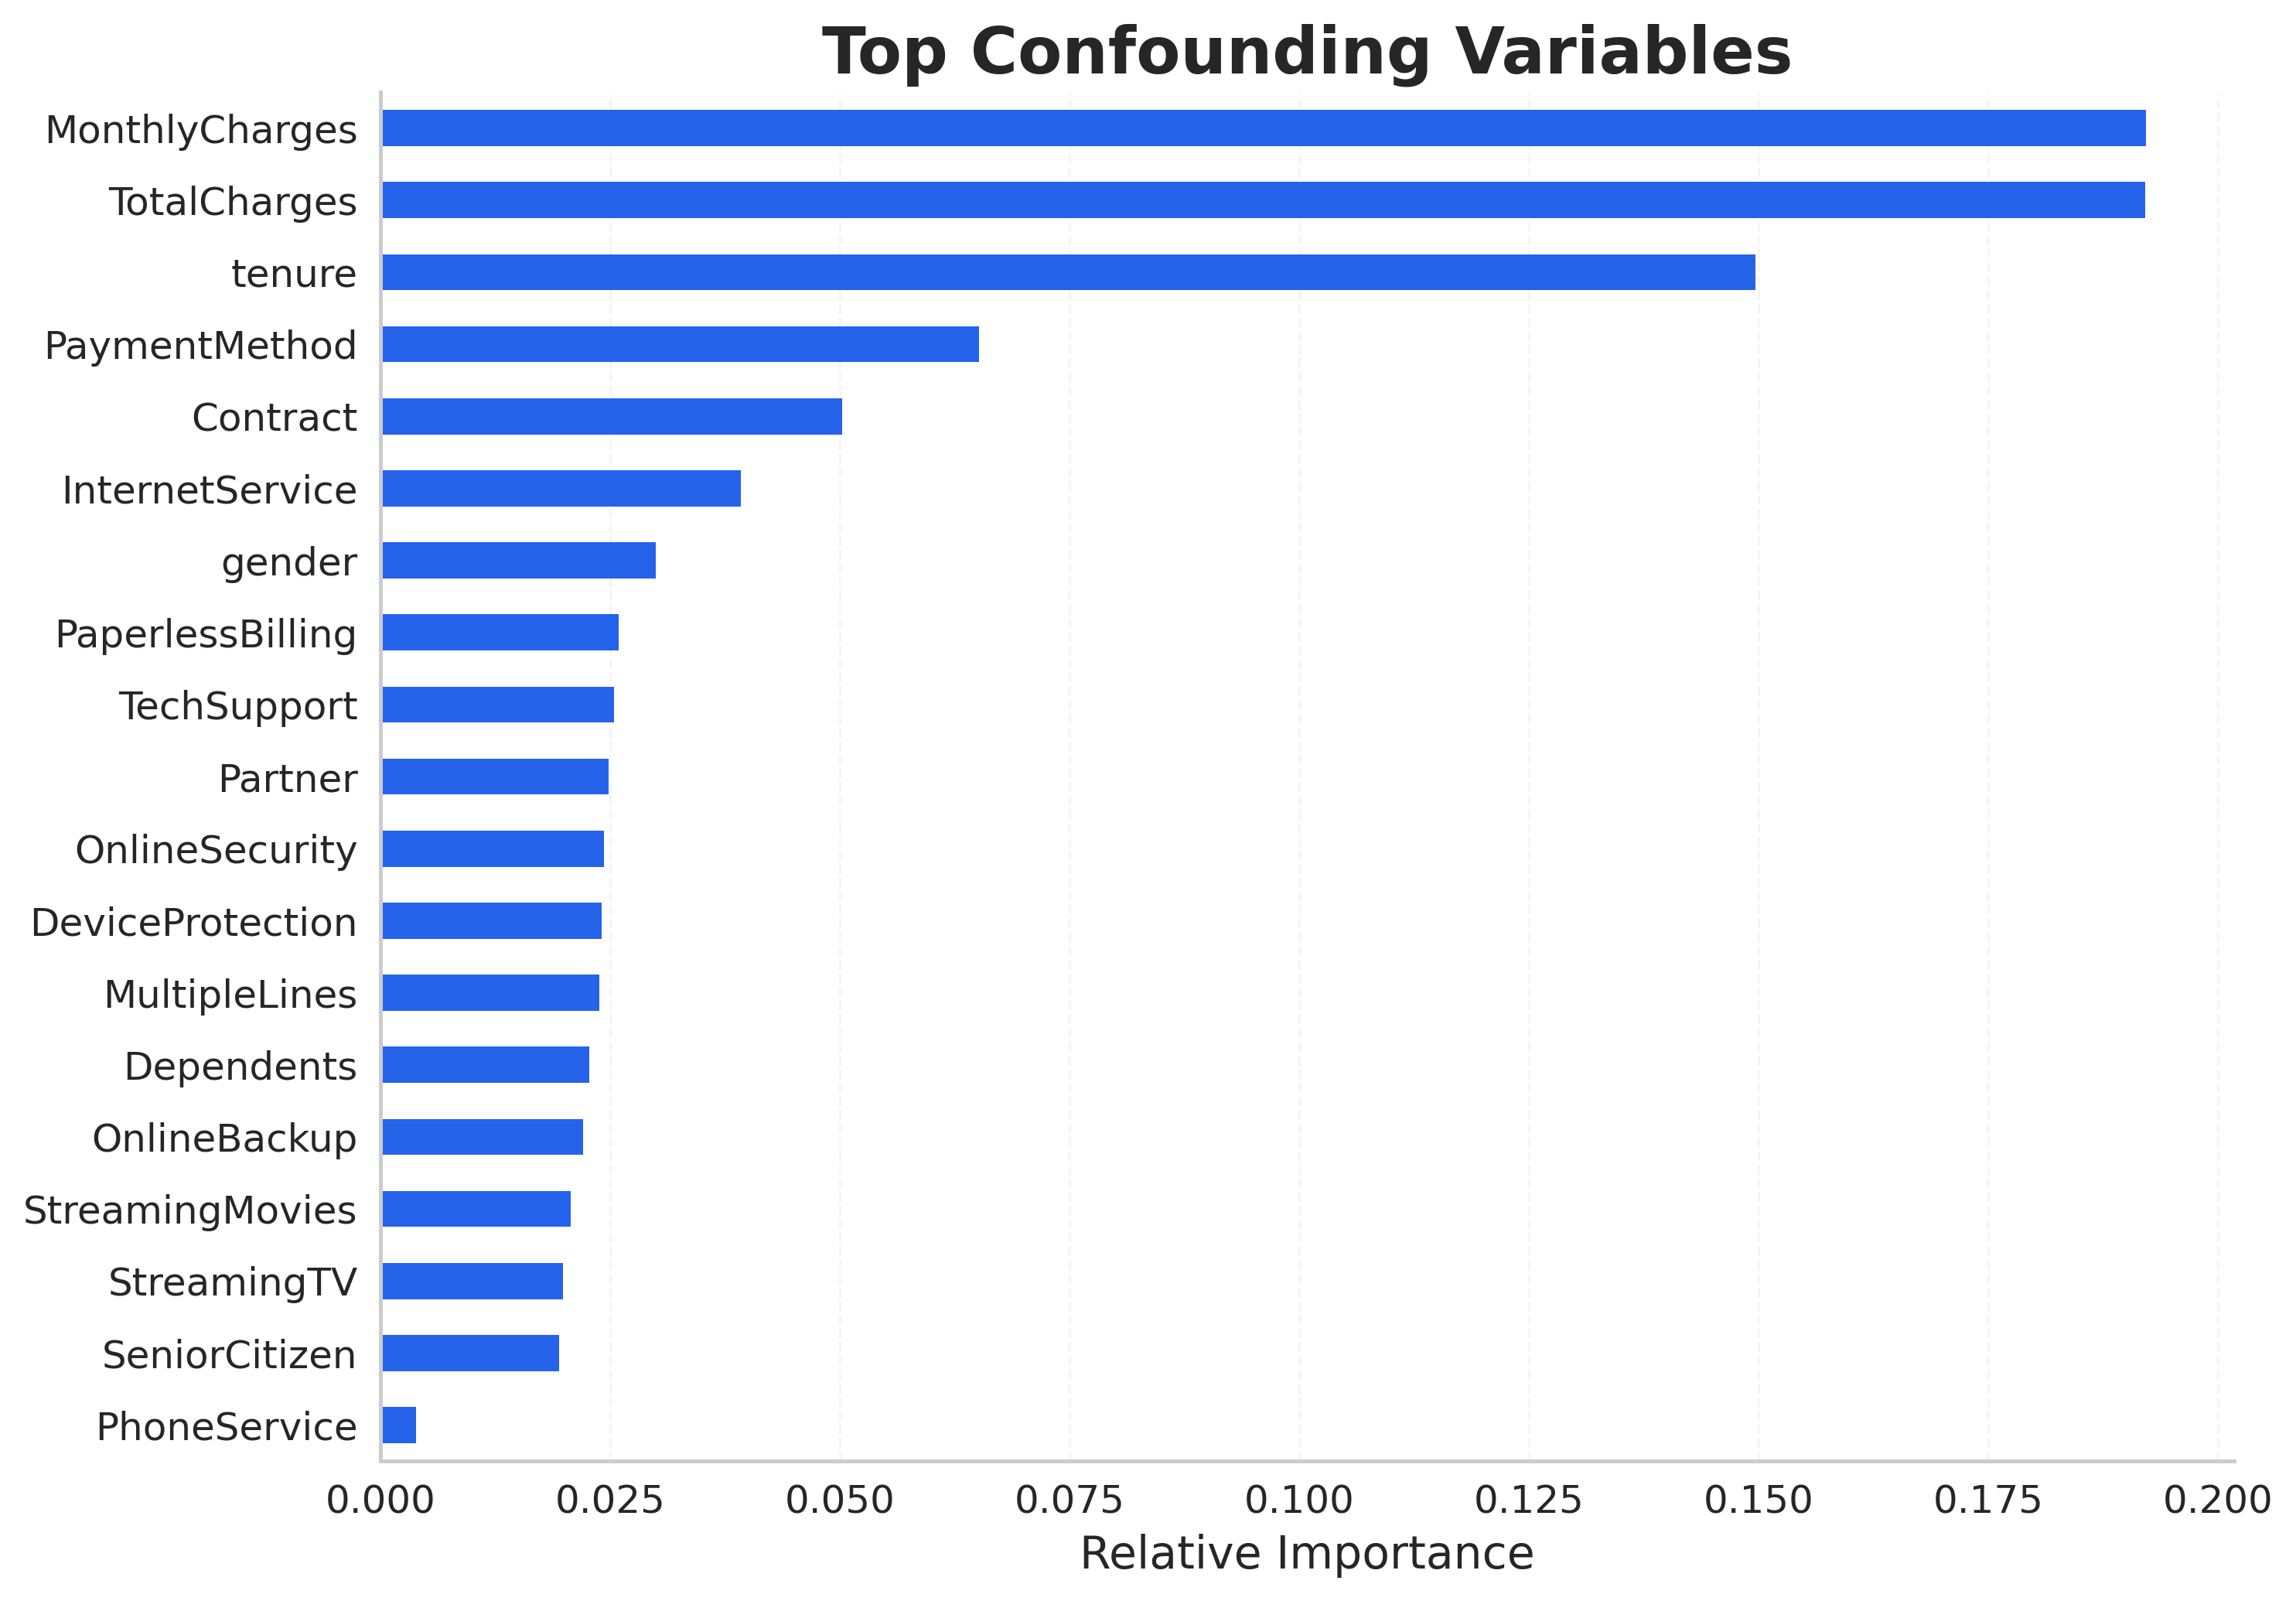

In [ ]:
plt.figure(figsize=(10,7))

plot_df = (
    importance_df["Confounder_Score"]
    .sort_values(ascending=True)
)

ax = plot_df.plot.barh(
    color="#2563EB",
    edgecolor="none"
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.set_xlabel("Relative Importance", fontsize=14)
ax.set_ylabel("")
ax.set_title("Top Confounding Variables", fontsize=20, weight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "01_confounders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

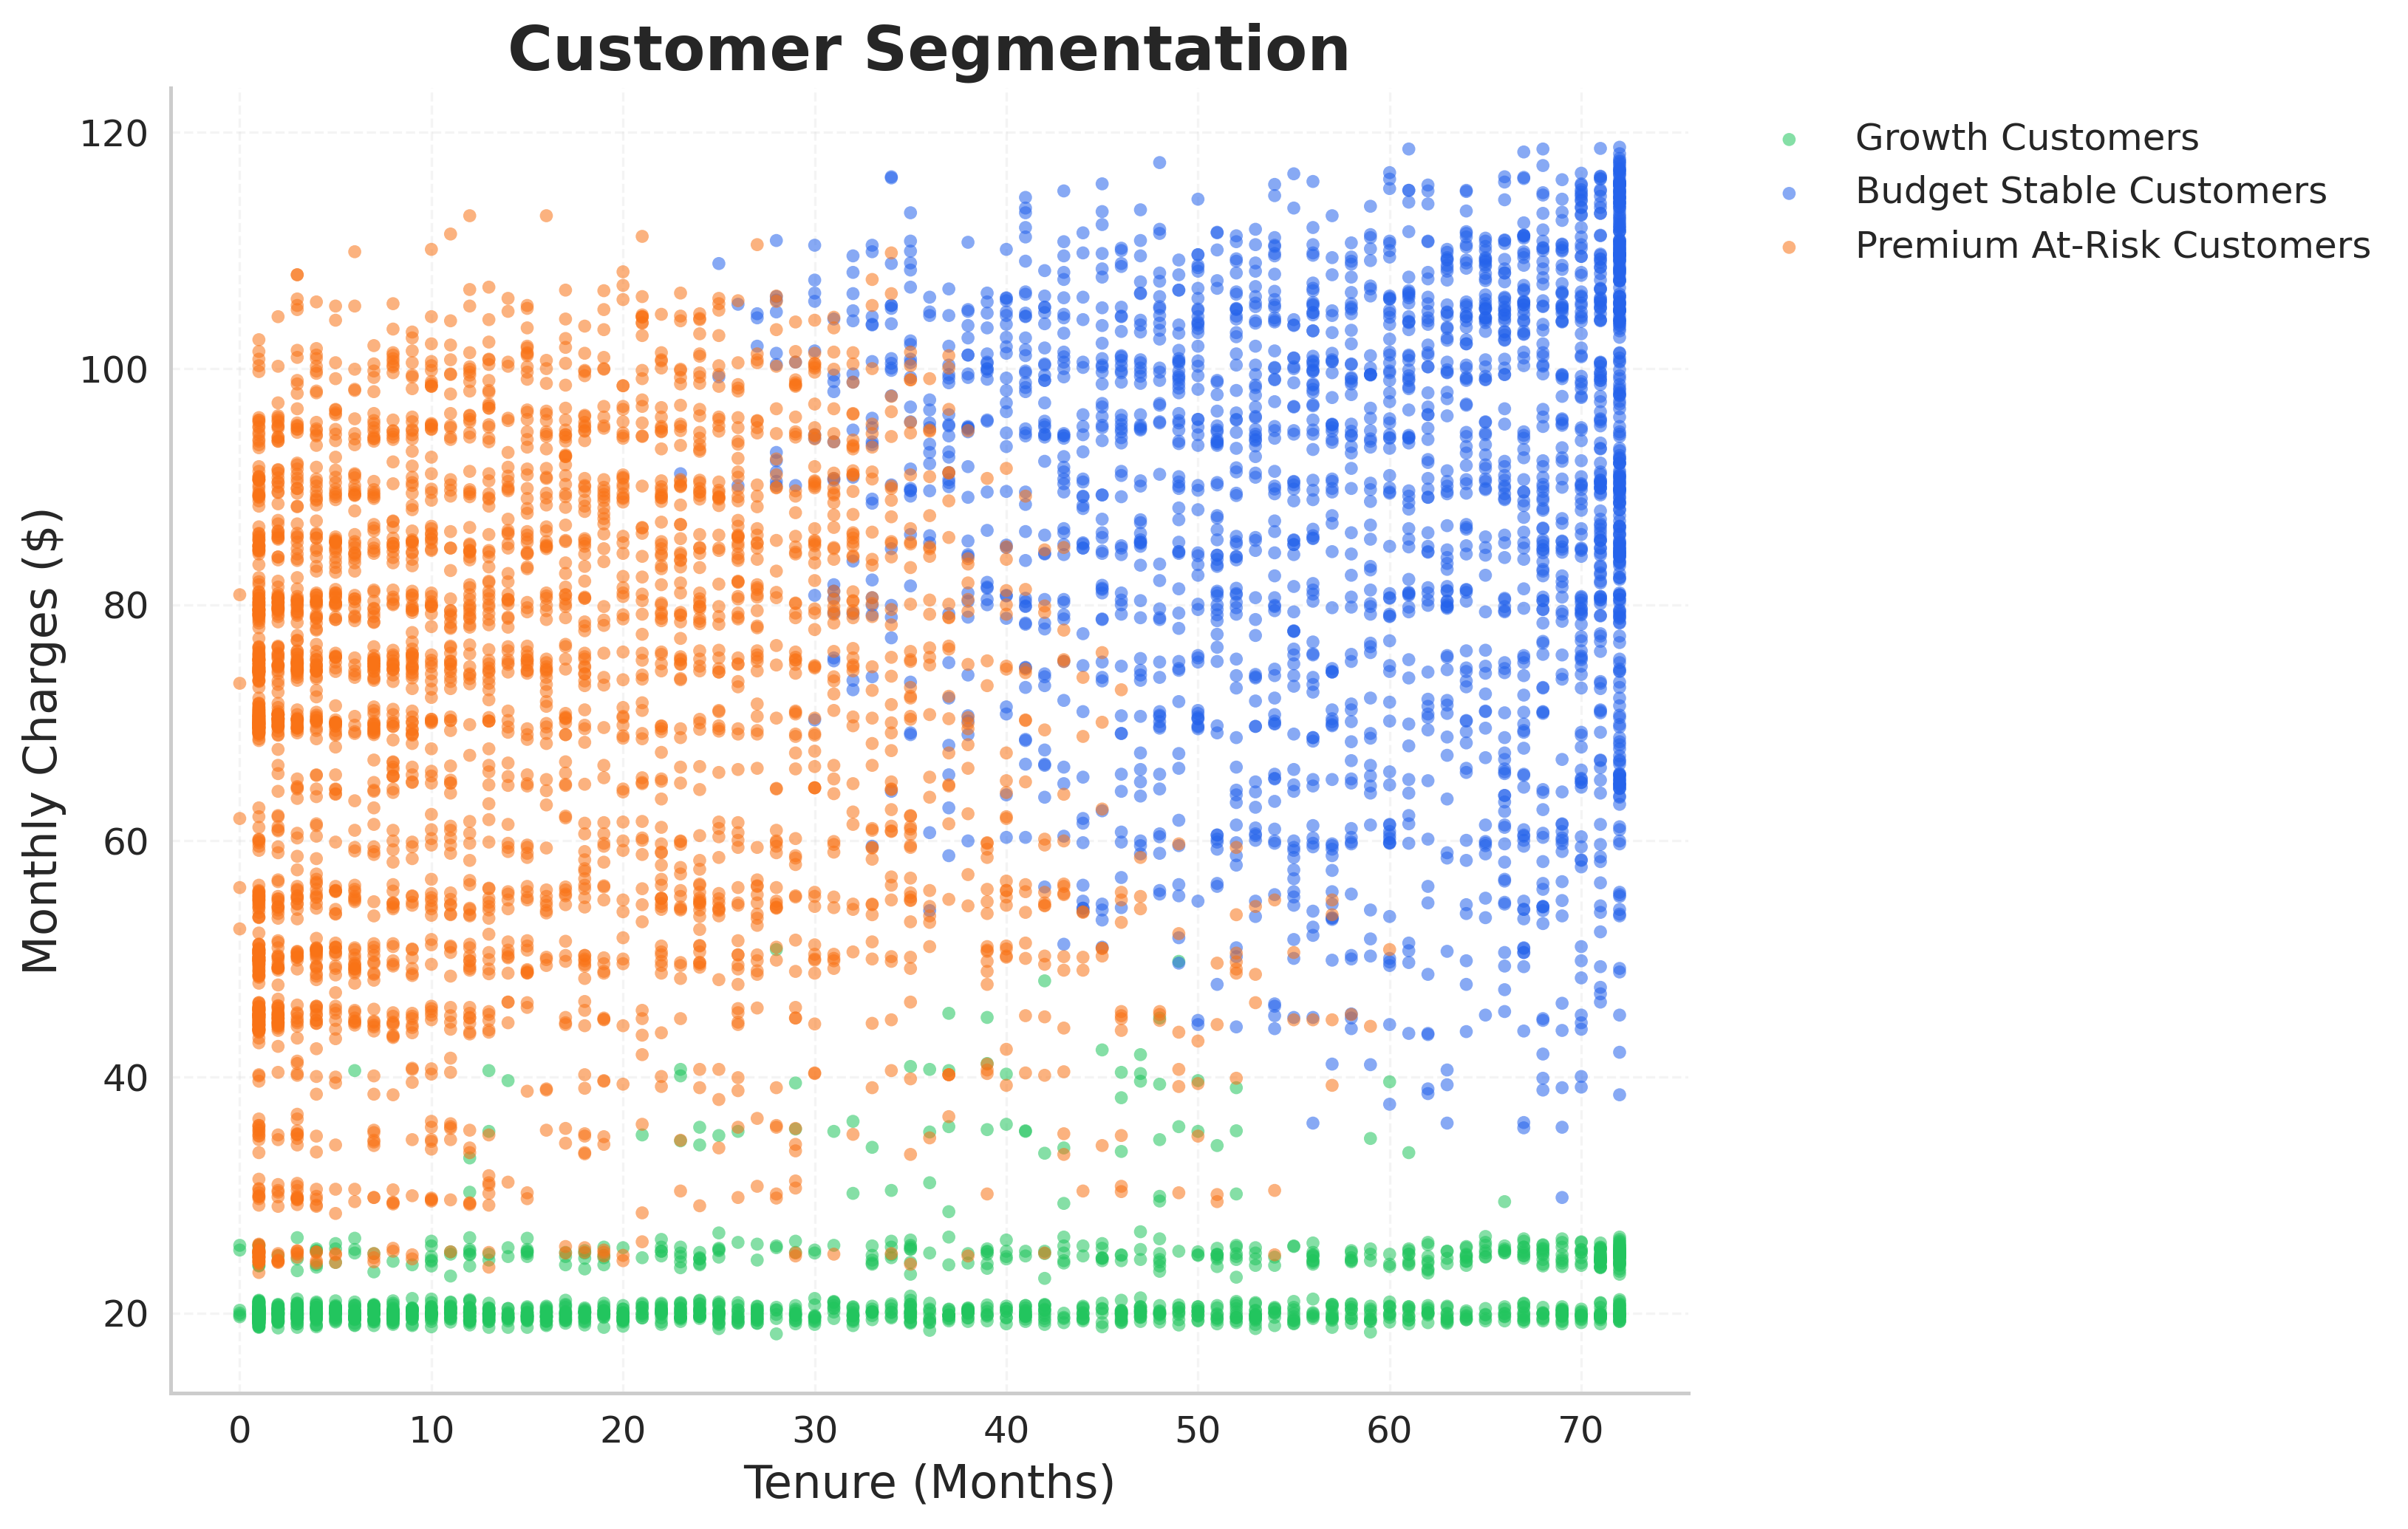

In [ ]:
segment_colors = {
    "Growth Customers":"#22C55E",
    "Budget Stable Customers":"#2563EB",
    "Premium At-Risk Customers":"#F97316"
}

plt.figure(figsize=(11,7))

for name,color in segment_colors.items():

    temp = df[df["Segment_Name"]==name]

    plt.scatter(
        temp["tenure"],
        temp["MonthlyCharges"],
        color=color,
        s=18,
        alpha=0.55,
        edgecolors="none",
        label=name
    )

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.title("Customer Segmentation")

plt.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

plt.savefig(
    "03_segmentation.png",
    dpi=300
)

plt.show()

In [ ]:
heatmap_df = segment_profile.copy()

heatmap_df.index = [
    "Growth",
    "Budget Stable",
    "Premium At-Risk"
]

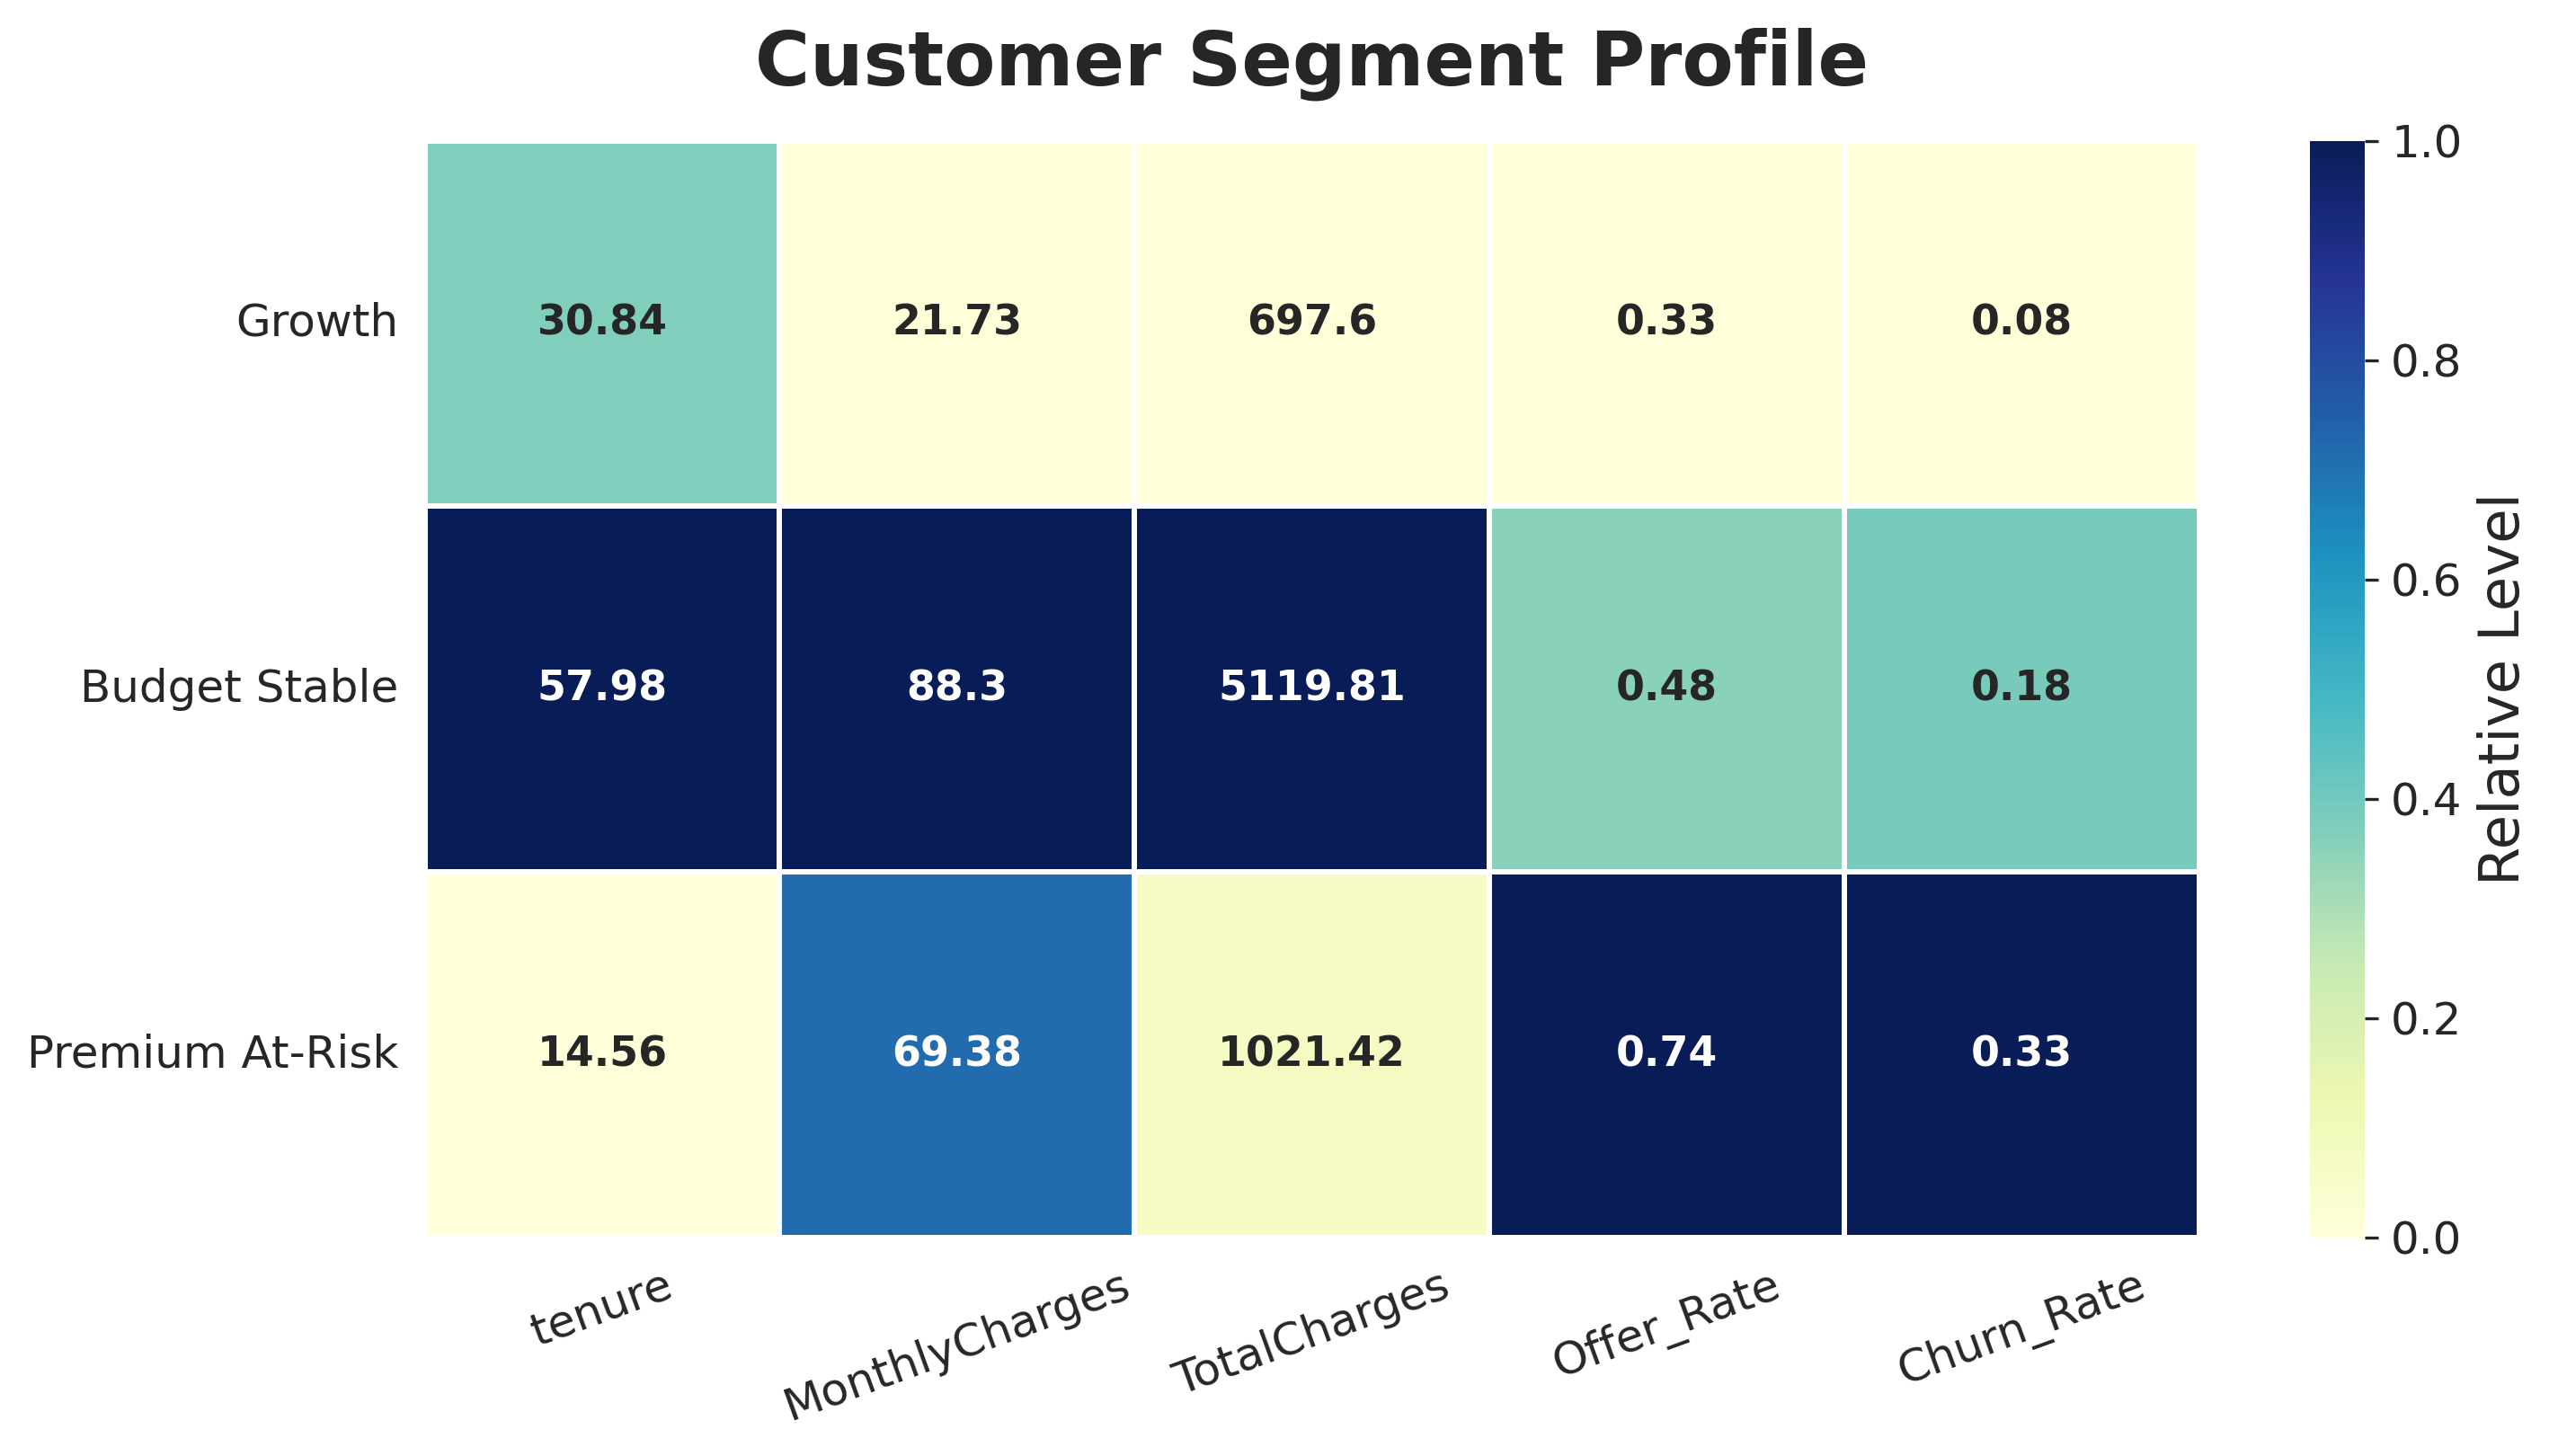

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Copy original values
heatmap_values = segment_profile.copy()

heatmap_values.index = [
    "Growth",
    "Budget Stable",
    "Premium At-Risk"
]

# Normalize each feature independently
scaler = MinMaxScaler()

heatmap_colors = pd.DataFrame(
    scaler.fit_transform(heatmap_values),
    columns=heatmap_values.columns,
    index=heatmap_values.index
)

plt.figure(figsize=(10,5.5))

sns.heatmap(
    heatmap_colors,
    annot=heatmap_values.round(2),
    fmt="",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label":"Relative Level"},
    annot_kws={
        "fontsize":11,
        "weight":"bold"
    }
)

plt.title(
    "Customer Segment Profile",
    fontsize=20,
    weight="bold",
    pad=15
)

plt.xticks(rotation=20)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "04_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

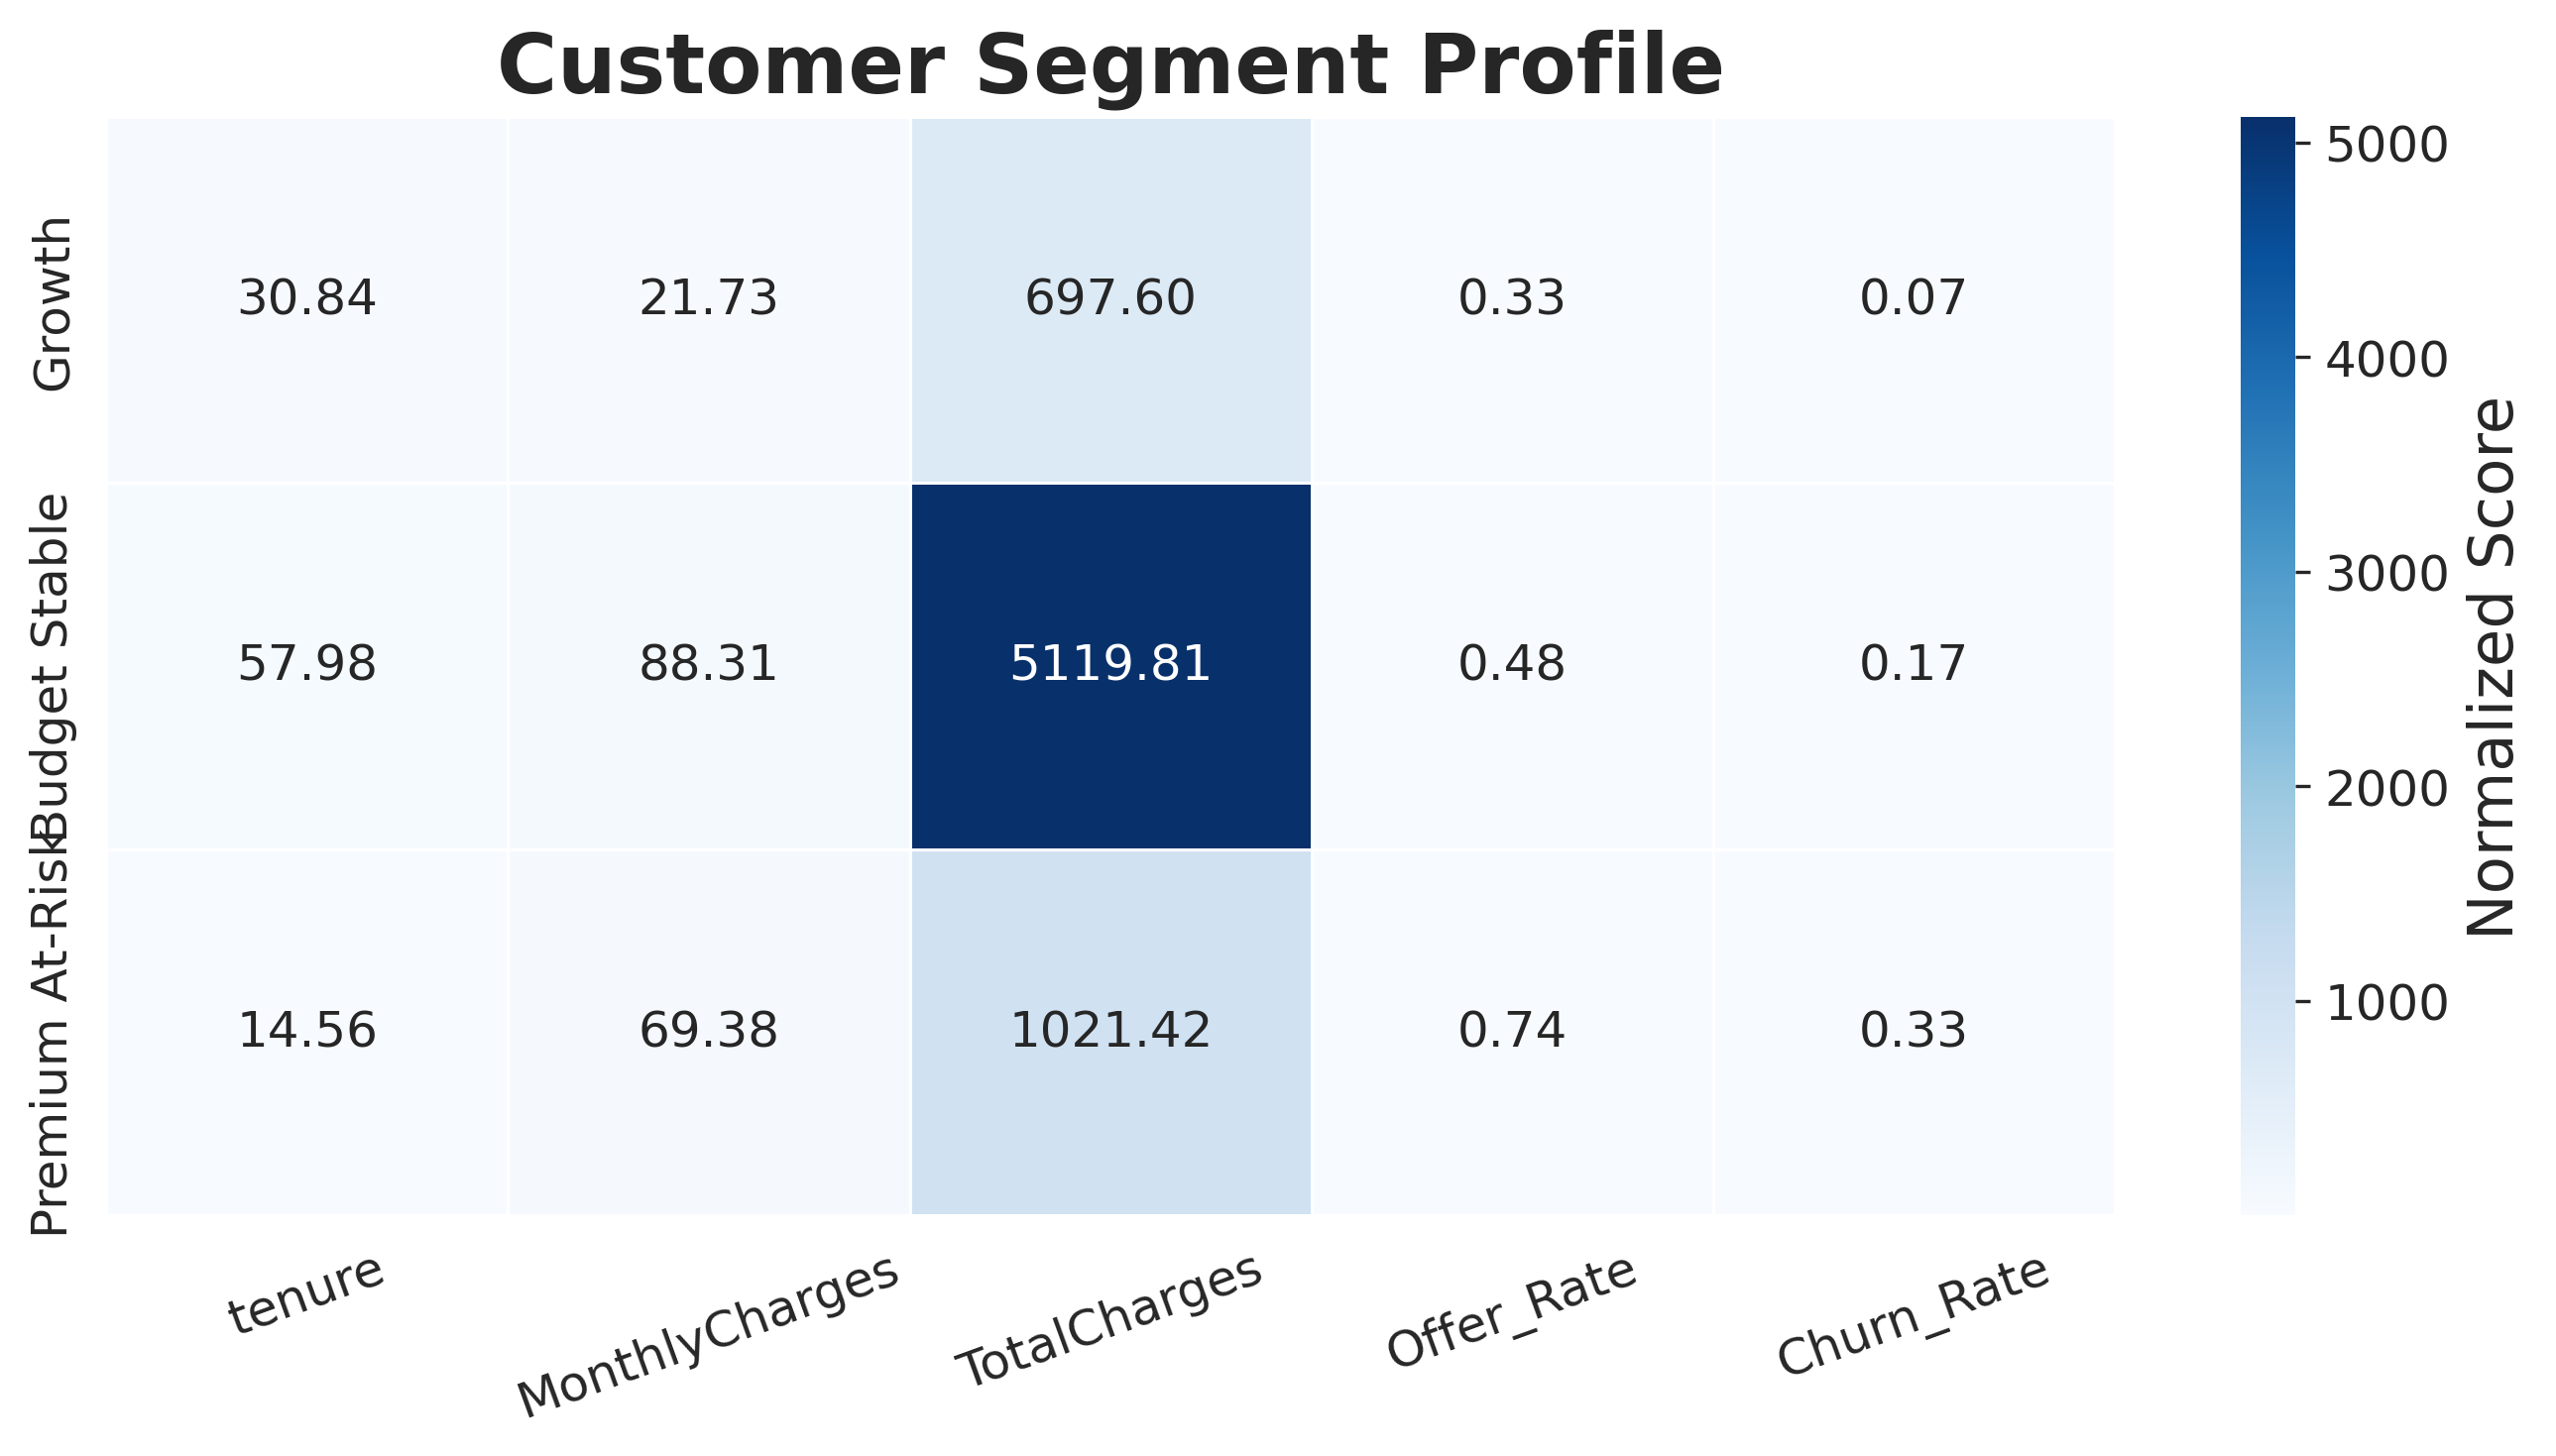

In [ ]:
plt.figure(figsize=(9,5))

sns.heatmap(

    heatmap_df,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    linewidths=.7,

    annot_kws={
        "fontsize":12
    },

    cbar_kws={
        "label":"Normalized Score"
    }

)

plt.xticks(rotation=20)

plt.title(
    "Customer Segment Profile",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "04_heatmap.png",
    dpi=300
)

plt.show()

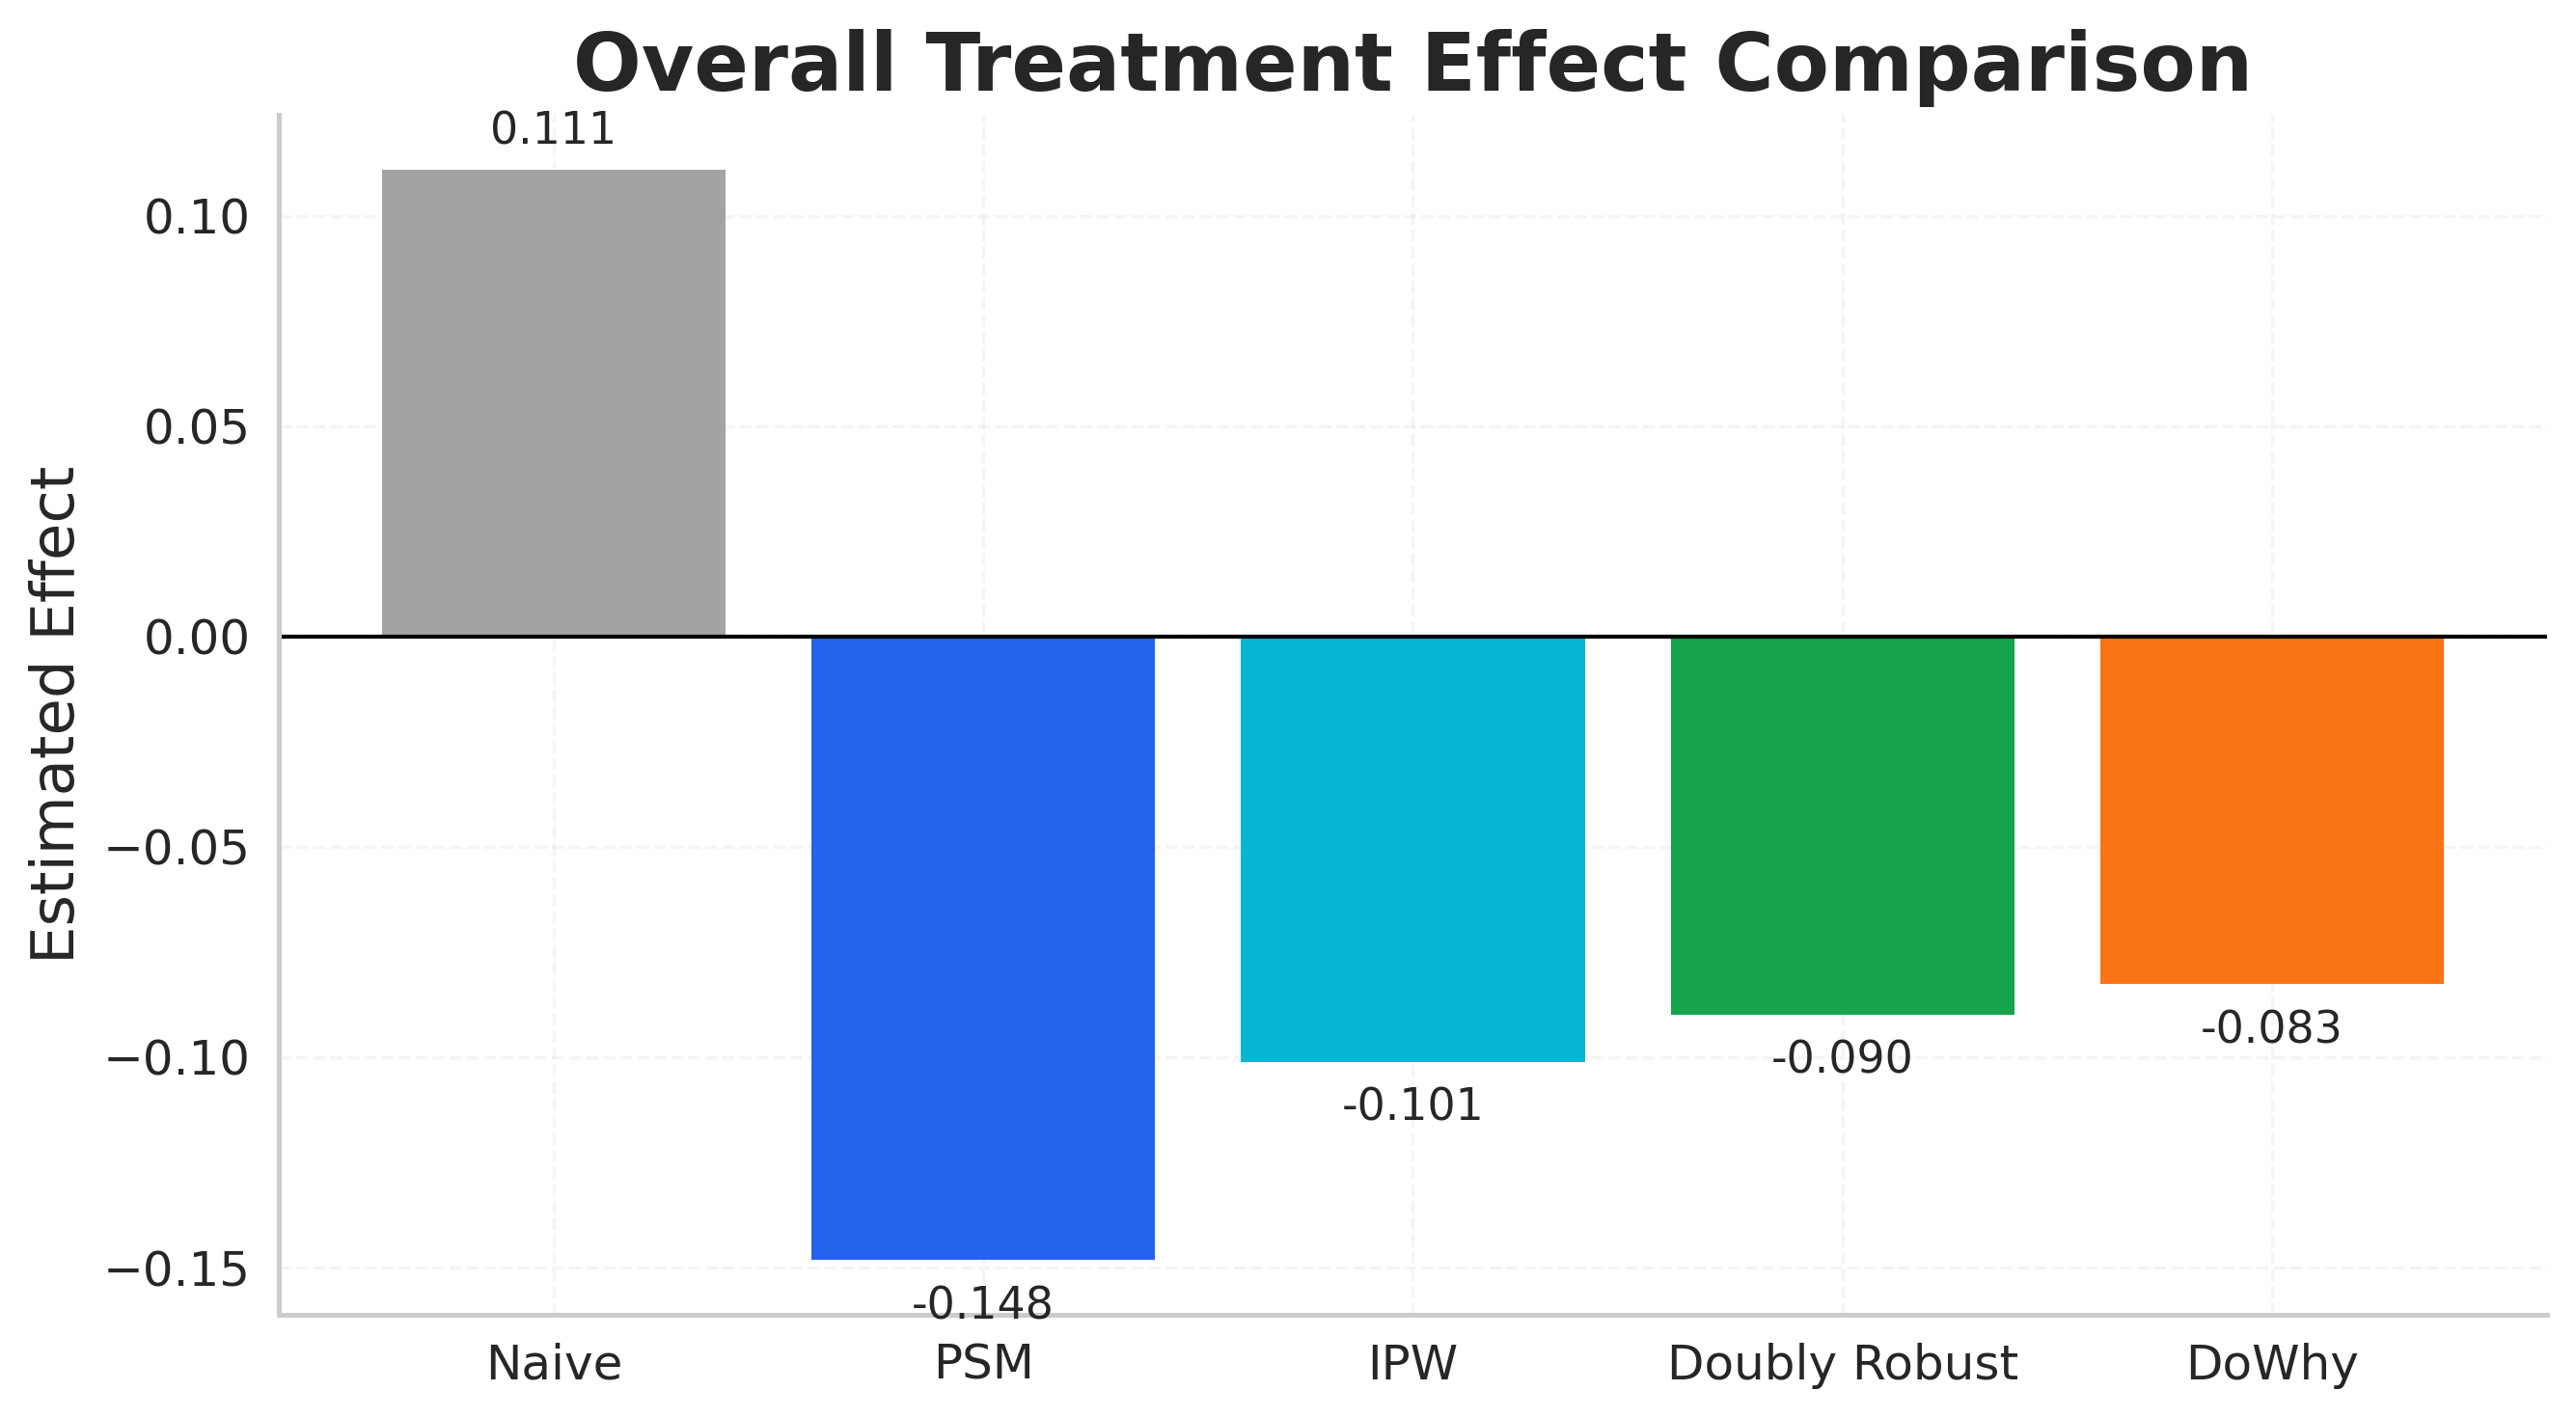

In [ ]:
colors = [
    "#A3A3A3",
    "#2563EB",
    "#06B6D4",
    "#16A34A",
    "#F97316"
]

plt.figure(figsize=(9,5))

bars = plt.bar(
    comparison["Method"],
    comparison["Estimated Effect"],
    color=colors,
    edgecolor="none"
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.ylabel("Estimated Effect")

plt.title(
    "Overall Treatment Effect Comparison",
    fontsize=20,
    weight="bold"
)

for bar in bars:

    h = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        h+0.006 if h>=0 else h-0.014,

        f"{h:.3f}",

        ha="center",

        fontsize=11

    )

plt.tight_layout()

plt.savefig(
    "05_overall_effect.png",
    dpi=300
)

plt.show()

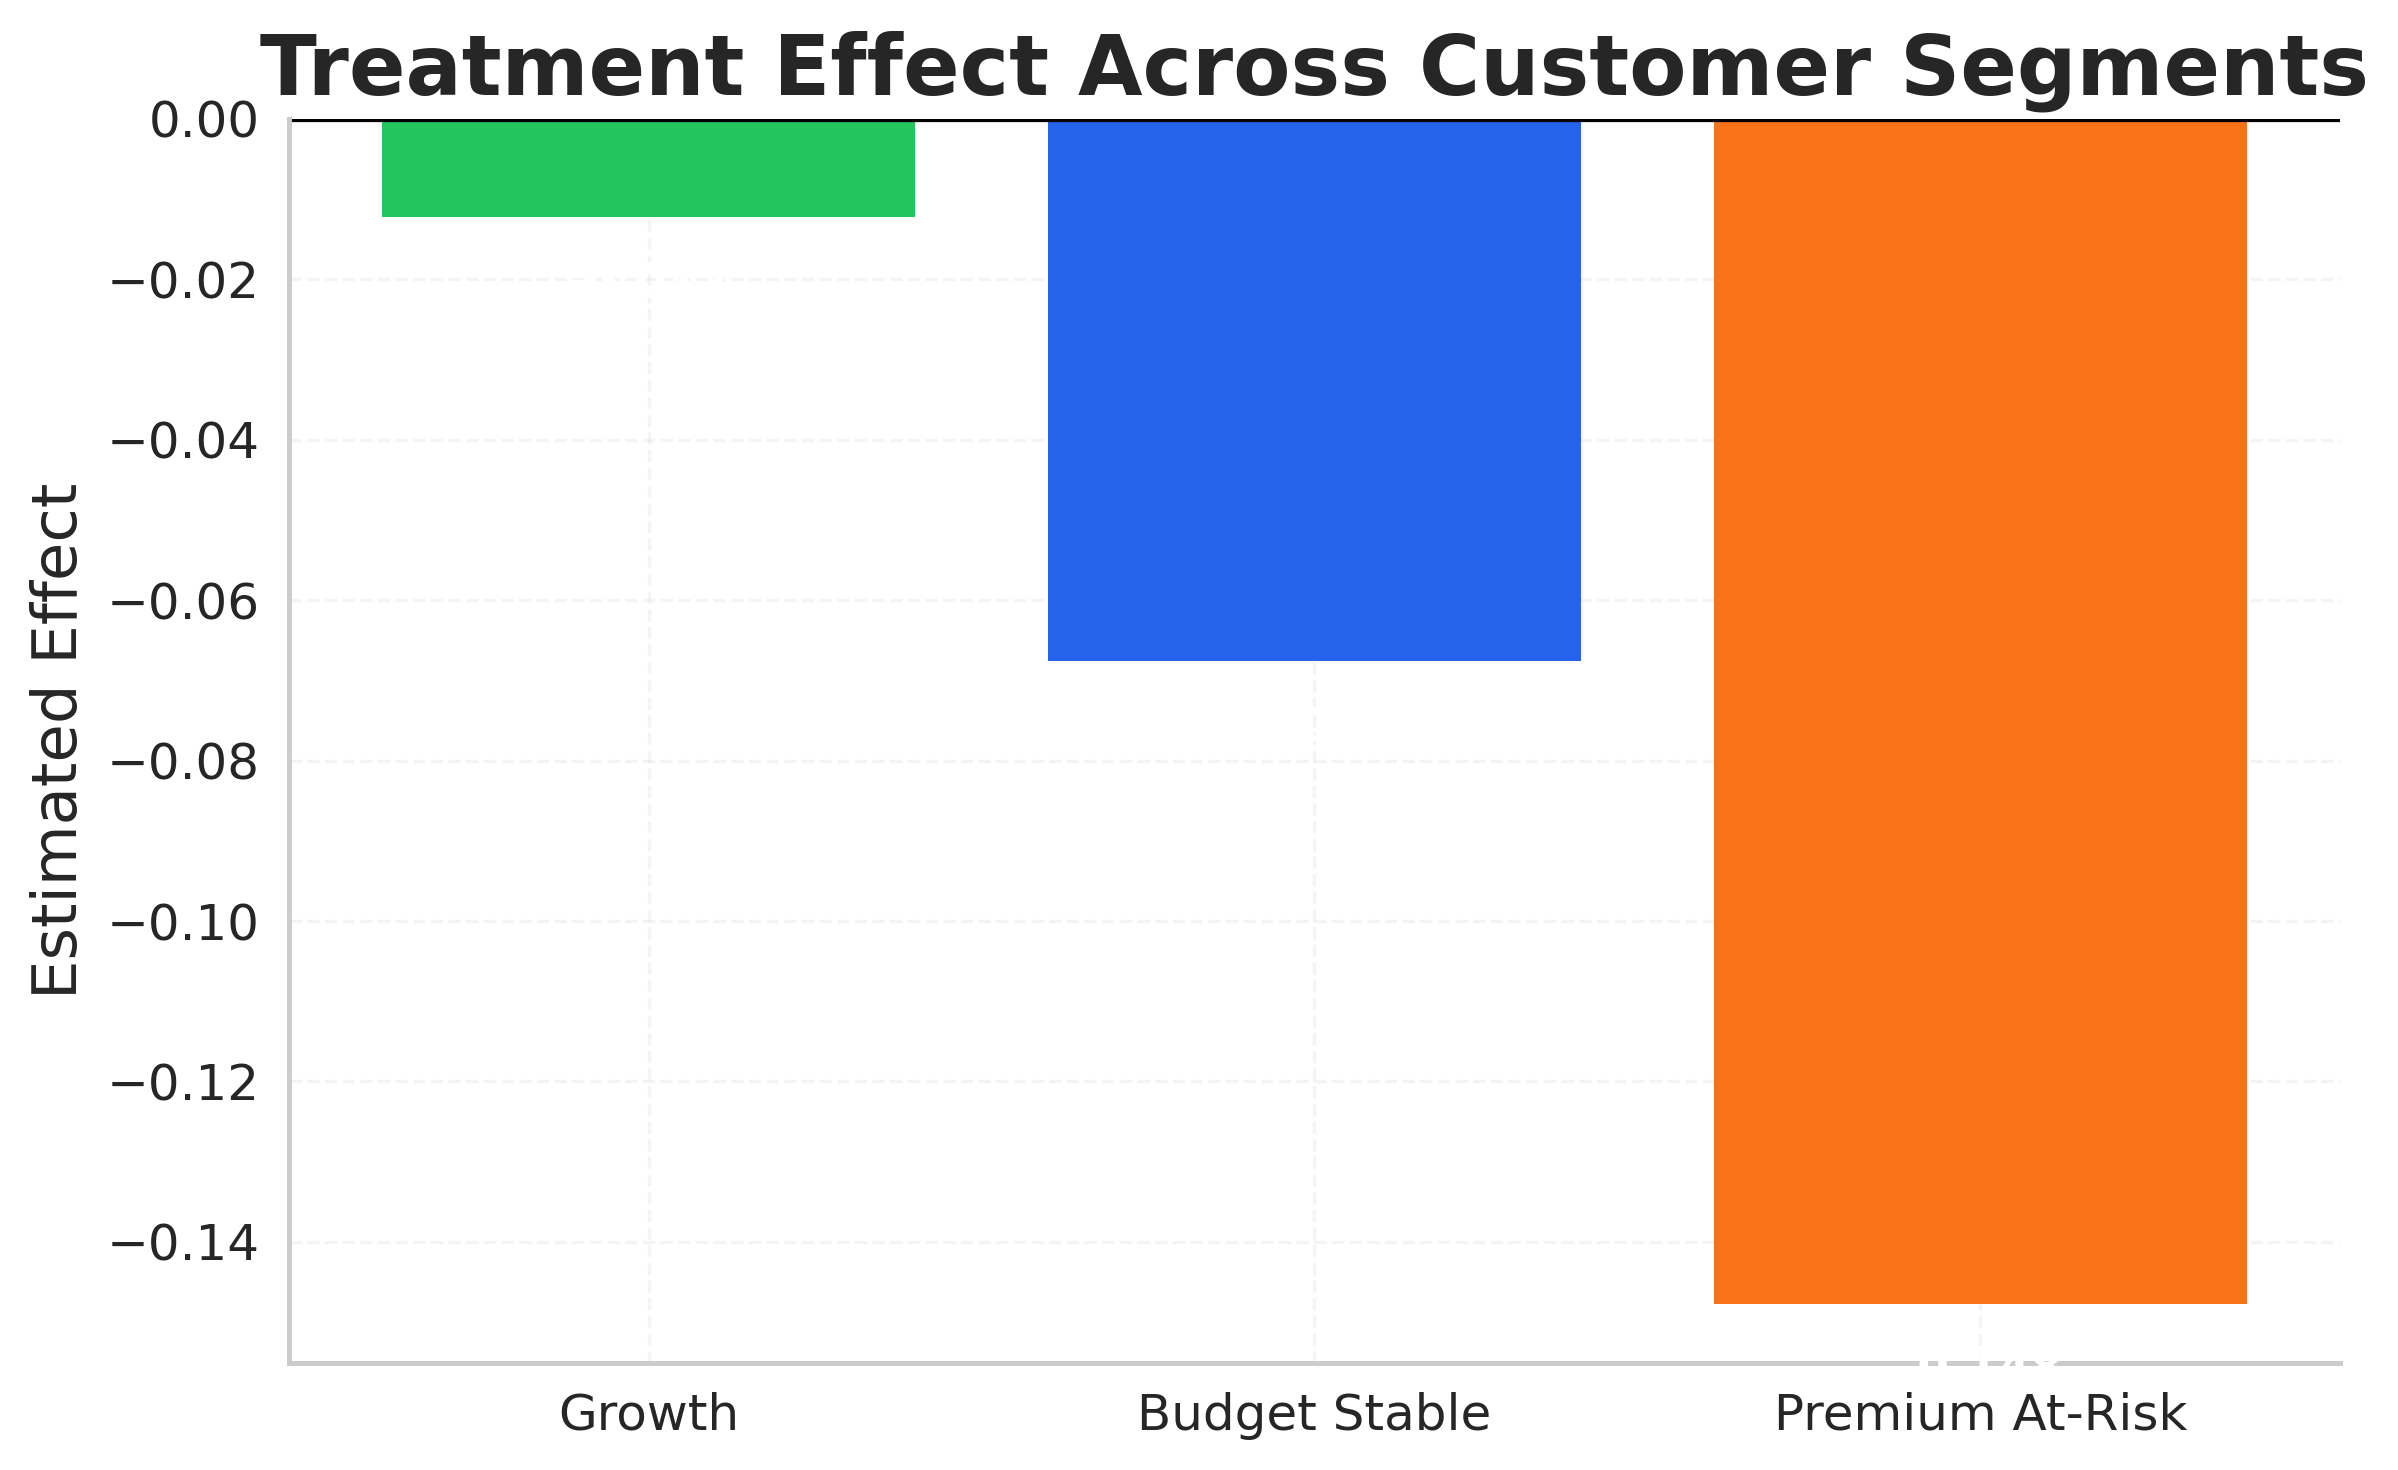

In [ ]:
segment_plot = segment_results.copy()

segment_plot["Segment"] = [
    "Growth",
    "Budget Stable",
    "Premium At-Risk"
]

colors = [
    "#22C55E",
    "#2563EB",
    "#F97316"
]

plt.figure(figsize=(8,5))

bars = plt.bar(

    segment_plot["Segment"],

    segment_plot["DoWhy_Effect"],

    color=colors,

    edgecolor="none"
)

plt.axhline(
    0,
    color="black"
)

plt.ylabel("Estimated Effect")

plt.title(
    "Treatment Effect Across Customer Segments",
    fontsize=20,
    weight="bold"
)

for bar in bars:

    h = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        h-0.01,

        f"{h:.3f}",

        ha="center",

        color="white",

        fontsize=11,

        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "06_segment_effect.png",
    dpi=300
)

plt.show()